# **Exploratory Data Analysis — 10-K Filing Features**

In [ ]:
#!pip install pandas numpy matplotlib seaborn scikit-learn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

FEATURES_PATH = '../data/finbert_features/merged_features_labels.csv'

df = pd.read_csv(FEATURES_PATH)

# Define column groups
PILLAR_SCORES  = ['E_pillar_score', 'S_pillar_score', 'G_pillar_score']
ESG_SCORES     = ['environment_score', 'social_score', 'governance_score', 'total_score']
SENTIMENT_COLS = [f'{p}_{s}' for p in ['E','S','G']
                  for s in ['pos_mean','neg_mean','neu_mean']]
KW_FREQ_COLS   = [c for c in df.columns if c.startswith('kw_') and c.endswith('_freq')]
KW_PRES_COLS   = [c for c in df.columns if c.startswith('kw_') and c.endswith('_present')]
STRUCT_COLS    = ['doc_length','business_length','risk_factors_length','mda_length']
PCT_COLS       = ['business_pct','risk_factors_pct','mda_pct']
COVERAGE_COLS  = ['E_coverage_pct','S_coverage_pct','G_coverage_pct']
QUANT_HAS_COLS = [c for c in df.columns if c.startswith('has_')]
QUANT_CNT_COLS = [c for c in df.columns if c.startswith('count_')]
PILLAR_COLORS  = {'E': '#2ecc71', 'S': '#3498db', 'G': '#9b59b6'}

print(f'Loaded {len(df)} companies × {len(df.columns)} columns')

Loaded 332 companies × 83 columns


In [3]:
# ── FINBERT SENTIMENT HELPERS ──────────────────────────────────────────────────
def plot_pillar_scores(df):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, col, label, color in zip(axes, PILLAR_SCORES,
                                      ['Environment','Social','Governance'],
                                      [PILLAR_COLORS['E'],PILLAR_COLORS['S'],PILLAR_COLORS['G']]):
        sns.histplot(df[col], bins=25, kde=True, ax=ax, color=color)
        ax.axvline(df[col].mean(),   color='black', linestyle='--', linewidth=1.2,
                   label=f'Mean: {df[col].mean():.1f}')
        ax.axvline(df[col].median(), color='grey',  linestyle=':',  linewidth=1.2,
                   label=f'Median: {df[col].median():.1f}')
        ax.set_title(f'{label} Pillar Score')
        ax.set_xlabel('FinBERT Pillar Score (0–100)')
        ax.legend(fontsize=8)
    plt.suptitle('FinBERT Composite Pillar Score Distributions', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

def plot_sentiment_breakdown(df):
    sentiments = ['pos_mean','neg_mean','neu_mean']
    labels     = ['Positive','Negative','Neutral']
    colors     = ['#2ecc71','#e74c3c','#95a5a6']
    fig, axes  = plt.subplots(1, 3, figsize=(14, 5))
    for ax, (pillar, pname) in zip(axes, [('E','Environment'),('S','Social'),('G','Governance')]):
        data = [df[f'{pillar}_{s}'].dropna() for s in sentiments]
        bp   = ax.boxplot(data, patch_artist=True, widths=0.5,
                          medianprops=dict(color='black', linewidth=2))
        for patch, c in zip(bp['boxes'], colors):
            patch.set_facecolor(c); patch.set_alpha(0.7)
        ax.set_xticks([1,2,3]); ax.set_xticklabels(labels)
        ax.set_ylabel('Probability'); ax.set_title(f'{pname} Pillar')
    plt.suptitle('FinBERT Sentiment Probability Breakdown by Pillar', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

def plot_sentence_counts(df):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, pillar, label, color in zip(axes, ['E','S','G'],
                                         ['Environment','Social','Governance'],
                                         [PILLAR_COLORS['E'],PILLAR_COLORS['S'],PILLAR_COLORS['G']]):
        col     = f'{pillar}_sentence_count'
        sns.histplot(df[col], bins=20, ax=ax, color=color)
        ax.axvline(100, color='red', linestyle='--', linewidth=1, label='Cap (100)')
        at_cap  = (df[col] >= 100).mean() * 100
        ax.set_title(label); ax.set_xlabel('Sentence Count')
        ax.legend(title=f'{at_cap:.0f}% at cap', fontsize=8)
    plt.suptitle('ESG-Relevant Sentence Counts by Pillar (capped at 100)', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

# ── KEYWORD HELPERS ─────────────────────────────────────────────────────────────
KW_LABELS = {
    'carbon_emissions':'Carbon Emissions','renewable_energy':'Renewable Energy',
    'climate_risk':'Climate Risk','waste_water':'Waste & Water',
    'diversity':'Diversity','employee_welfare':'Employee Welfare',
    'human_rights':'Human Rights','community':'Community',
    'board_governance':'Board Governance','executive_pay':'Executive Pay',
    'ethics_compliance':'Ethics & Compliance','transparency':'Transparency',
    'regulatory_penalties':'Regulatory Penalties','controversy':'Controversy',
}

def plot_keyword_presence(df):
    pres = {KW_LABELS[k.replace('kw_','').replace('_present','')]: df[k].mean()*100
            for k in KW_PRES_COLS if k.replace('kw_','').replace('_present','') in KW_LABELS}
    s = pd.Series(pres).sort_values()
    colors = ['#e74c3c' if v<50 else '#3498db' if v<90 else '#2ecc71' for v in s.values]
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(s.index, s.values, color=colors, edgecolor='white')
    ax.axvline(100, color='grey', linestyle='--', linewidth=1)
    ax.set_xlabel('% of Companies with Keyword Present')
    ax.set_title('ESG Keyword Topic Presence Rates across 10-K Filings', fontsize=12)
    ax.set_xlim(0, 115)
    for bar, val in zip(bars, s.values):
        ax.text(val+1, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
    plt.tight_layout(); plt.show()

def plot_keyword_freq_distributions(df, top_n=6):
    stds     = {c: df[c].std() for c in KW_FREQ_COLS}
    top_cols = sorted(stds, key=stds.get, reverse=True)[:top_n]
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    for ax, col in zip(axes.flatten(), top_cols):
        key   = col.replace('kw_','').replace('_freq','')
        label = KW_LABELS.get(key, key)
        data  = df[col][df[col] > 0]
        sns.histplot(data, bins=25, ax=ax, color='#3498db')
        ax.set_title(label); ax.set_xlabel('Freq per 1,000 words (non-zero)')
        ax.text(0.97, 0.95, f'n={len(data)}', transform=ax.transAxes,
                ha='right', va='top', fontsize=9, color='grey')
    plt.suptitle('Keyword Frequency Distributions (Top 6 Most Variable Topics)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

# ── DOCUMENT STRUCTURE HELPERS ─────────────────────────────────────────────────
def plot_doc_length_distribution(df):
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(df['doc_length'], bins=30, kde=True, ax=ax, color='#3498db')
    ax.axvline(df['doc_length'].mean(),   color='black', linestyle='--', linewidth=1.2,
               label=f'Mean: {df["doc_length"].mean():,.0f}')
    ax.axvline(df['doc_length'].median(), color='grey',  linestyle=':',  linewidth=1.2,
               label=f'Median: {df["doc_length"].median():,.0f}')
    ax.set_xlabel('Total Document Length (words)')
    ax.set_title('Distribution of 10-K Document Length (3-Section Combined)', fontsize=12)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
    ax.legend(); plt.tight_layout(); plt.show()

def plot_section_proportions(df):
    labels = ['Business\n(Item 1)','Risk Factors\n(Item 1A)','MD&A\n(Item 7)']
    data   = [df['business_pct']*100, df['risk_factors_pct']*100, df['mda_pct']*100]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    bp = axes[0].boxplot(data, labels=labels, patch_artist=True,
                          medianprops=dict(color='black', linewidth=2), widths=0.5)
    for patch, c in zip(bp['boxes'], ['#f39c12','#e74c3c','#3498db']):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    axes[0].set_ylabel('% of Document'); axes[0].set_title('Section Proportion Distribution')
    means  = [df[c].mean()*100 for c in PCT_COLS]
    lefts  = [0, means[0], means[0]+means[1]]
    clrs   = ['#f39c12','#e74c3c','#3498db']
    lbls   = ['Business','Risk Factors','MD&A']
    for i, (m, l, c, lbl) in enumerate(zip(means, lefts, clrs, lbls)):
        axes[1].barh(['Mean split'], [m], left=[l], color=c, label=lbl)
        axes[1].text(l+m/2, 0, f'{m:.1f}%', ha='center', va='center',
                     fontsize=10, color='white', fontweight='bold')
    axes[1].set_xlim(0, 100); axes[1].set_xlabel('% of Document')
    axes[1].set_title('Average Section Split'); axes[1].legend(loc='lower right')
    plt.suptitle('10-K Section Length Proportions', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

def plot_esg_coverage(df):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, col, label, color in zip(axes, COVERAGE_COLS,
                                      ['Environment','Social','Governance'],
                                      [PILLAR_COLORS['E'],PILLAR_COLORS['S'],PILLAR_COLORS['G']]):
        sns.histplot(df[col]*100, bins=25, kde=True, ax=ax, color=color)
        ax.set_xlabel('% of Document Sentences'); ax.set_title(f'{label} Coverage')
        ax.axvline(df[col].mean()*100, color='black', linestyle='--', linewidth=1,
                   label=f'Mean: {df[col].mean()*100:.1f}%')
        ax.legend(fontsize=8)
    plt.suptitle('ESG Pillar Sentence Coverage (% of Total Document)', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

# ── QUANTITATIVE SIGNAL HELPERS ─────────────────────────────────────────────────
def plot_signal_presence(df):
    labels_map = {
        'has_sustainability_mention':'Sustainability Mention','has_emissions_numbers':'Emissions Numbers',
        'has_dollar_fines':'Dollar Fines Disclosed','has_employee_numbers':'Employee Headcount',
        'has_percent_renewable':'Renewable % Disclosed','has_women_leadership':'Women in Leadership',
        'has_board_independence':'Board Independence',
    }
    pres = {labels_map.get(c,c): df[c].mean()*100 for c in QUANT_HAS_COLS}
    s    = pd.Series(pres).sort_values(ascending=False)
    clrs = ['#2ecc71' if v>50 else '#f39c12' if v>10 else '#e74c3c' for v in s.values]
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(s.index, s.values, color=clrs, edgecolor='white')
    ax.set_ylabel('% of Companies'); ax.set_ylim(0, 110)
    ax.set_title('Quantitative Signal Presence Rates across 10-K Filings', fontsize=12)
    plt.xticks(rotation=30, ha='right')
    for bar, val in zip(bars, s.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
                f'{val:.1f}%', ha='center', fontsize=9)
    plt.tight_layout(); plt.show()

def plot_count_distributions(df):
    useful = [('count_emissions_numbers','Emissions Count'),
              ('count_employee_numbers','Employee Count Mentions'),
              ('count_dollar_fines','Dollar Fine Count'),
              ('count_percent_renewable','Renewable % Mentions')]
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    for ax, (col, label) in zip(axes, useful):
        data = df[df[col]>0][col]
        sns.histplot(data, bins=20, ax=ax, color='#9b59b6')
        ax.set_title(label); ax.set_xlabel(f'Count (n={len(data)} non-zero)')
    plt.suptitle('Count Feature Distributions (Non-Zero Only)', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

# ── CORRELATION HELPERS ─────────────────────────────────────────────────────────
def plot_feature_esg_correlations(df, feature_group, group_label, top_n=12):
    num_df    = df.select_dtypes(include='number')
    feat_cols = [c for c in feature_group if c in num_df.columns]
    corr_df   = num_df[feat_cols + ESG_SCORES].corr()
    corr_with = corr_df.loc[feat_cols, ESG_SCORES]
    corr_with = corr_with.reindex(
        corr_with['total_score'].abs().sort_values(ascending=False).index).head(top_n)
    fig, ax = plt.subplots(figsize=(10, max(5, len(corr_with)*0.4)))
    corr_with.plot(kind='barh', ax=ax, colormap='Set2', edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Pearson Correlation')
    ax.set_title(f'Top {top_n} {group_label} — Correlation with ESG Scores', fontsize=12)
    ax.legend(title='ESG Score', bbox_to_anchor=(1.01,1), loc='upper left')
    plt.tight_layout(); plt.show()

def plot_correlation_heatmap(df, feature_cols, row_label):
    num_df    = df.select_dtypes(include='number')
    feat_cols = [c for c in feature_cols if c in num_df.columns]
    corr_df   = num_df[feat_cols + ESG_SCORES].corr()
    cross     = corr_df.loc[feat_cols, ESG_SCORES]
    fig, ax   = plt.subplots(figsize=(8, max(4, len(feat_cols)*0.35)))
    sns.heatmap(cross, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                linewidths=0.5, ax=ax, vmin=-0.6, vmax=0.6)
    ax.set_title(f'{row_label} vs. ESG Scores', fontsize=12)
    ax.set_xlabel('ESG Score'); plt.tight_layout(); plt.show()

# ── INDUSTRY HELPERS ───────────────────────────────────────────────────────────
def get_top_industries(df, n=12):
    return df['industry'].value_counts().head(n).index.tolist()

def plot_industry_pillar_scores(df, n=12):
    top    = get_top_industries(df, n)
    scores = (df[df['industry'].isin(top)].groupby('industry')[PILLAR_SCORES]
              .mean().sort_values('E_pillar_score', ascending=False))
    scores.columns = ['Environment','Social','Governance']
    fig, ax = plt.subplots(figsize=(13, 5))
    scores.plot(kind='bar', ax=ax,
                color=[PILLAR_COLORS['E'],PILLAR_COLORS['S'],PILLAR_COLORS['G']],
                edgecolor='white', width=0.8)
    ax.set_title(f'Mean FinBERT Pillar Scores by Industry (Top {n})', fontsize=12)
    ax.set_ylabel('FinBERT Pillar Score (0-100)'); ax.set_xlabel('Industry')
    ax.legend(title='Pillar'); ax.set_ylim(40, 72)
    plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

def plot_industry_doc_length(df, n=12):
    top    = get_top_industries(df, n)
    pdf    = df[df['industry'].isin(top)]
    order  = pdf.groupby('industry')['doc_length'].median().sort_values(ascending=False).index
    fig, ax = plt.subplots(figsize=(13, 5))
    sns.boxplot(data=pdf, x='industry', y='doc_length', order=order, palette='Set3', ax=ax)
    ax.set_title(f'Document Length by Industry (Top {n})', fontsize=12)
    ax.set_xlabel('Industry'); ax.set_ylabel('Document Length (words)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
    plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

def plot_industry_env_coverage(df, n=12):
    top   = get_top_industries(df, n)
    means = (df[df['industry'].isin(top)].groupby('industry')['E_coverage_pct']
             .mean().sort_values(ascending=False))
    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(means.index, means.values*100, color=PILLAR_COLORS['E'], edgecolor='white')
    ax.set_ylabel('Mean Environment Sentence Coverage (%)')
    ax.set_title(f'Environment Sentence Coverage by Industry (Top {n})', fontsize=12)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                f'{val*100:.1f}%', ha='center', fontsize=8)
    plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

# ── FINBERT VS. ACTUAL ESG HELPERS ─────────────────────────────────────────────
def plot_finbert_vs_esg(df):
    pairs = [('E_pillar_score','environment_score','Environment',PILLAR_COLORS['E']),
             ('S_pillar_score','social_score',      'Social',     PILLAR_COLORS['S']),
             ('G_pillar_score','governance_score',  'Governance', PILLAR_COLORS['G'])]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (xc, yc, label, color) in zip(axes, pairs):
        ax.scatter(df[xc], df[yc], alpha=0.5, color=color, edgecolors='white', s=40)
        z  = np.polyfit(df[xc].dropna(), df[yc].dropna(), 1)
        xs = np.linspace(df[xc].min(), df[xc].max(), 100)
        ax.plot(xs, np.poly1d(z)(xs), color='black', linewidth=1.5, linestyle='--')
        corr = df[xc].corr(df[yc])
        ax.set_xlabel(f'FinBERT {label} Pillar Score')
        ax.set_ylabel(f'Actual {label} ESG Score')
        ax.set_title(f'{label}\nr = {corr:.3f}')
    plt.suptitle('FinBERT Pillar Scores vs. Actual ESG Pillar Scores', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

def plot_finbert_env_by_grade(df):
    grade_order = ['A','BBB','BB','B']
    palette     = {'A':'#2ecc71','BBB':'#3498db','BB':'#f39c12','B':'#e74c3c'}
    fig, axes   = plt.subplots(1, 3, figsize=(14, 5))
    for ax, (col, label) in zip(axes, [('E_pillar_score','Environment'),
                                        ('S_pillar_score','Social'),
                                        ('G_pillar_score','Governance')]):
        sns.boxplot(data=df, x='total_grade', y=col, order=grade_order, palette=palette, ax=ax)
        ax.set_xlabel('Total ESG Grade'); ax.set_ylabel('FinBERT Pillar Score')
        ax.set_title(f'{label} Pillar Score')
    plt.suptitle('FinBERT Pillar Scores by Total ESG Grade', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

print('All helper functions defined.')

All helper functions defined.


### ***Dataset Overview***

In [4]:
print(f'Shape: {df.shape}')
print(f'\nFeature groups:')
print(f'  FinBERT sentiment (E/S/G pillars):  {len(SENTIMENT_COLS) + 6} cols (pos/neg/neu mean+std, sentence_count, pos_neg_ratio)')
print(f'  FinBERT pillar scores:               3 cols (composite E/S/G score 0-100)')
print(f'  ESG keyword frequency:              {len(KW_FREQ_COLS)*2} cols ({len(KW_FREQ_COLS)} topic groups × freq + present)')
print(f'  Document structure:                  9 cols (lengths, pcts, pillar coverage %)')
print(f'  Quantitative signals:               {len(QUANT_HAS_COLS)+len(QUANT_CNT_COLS)} cols (has_* + count_* flags)')
print(f'  Target labels:                       5 cols (E/S/G/total score + grade)')
print(f'\nSample rows:')
df[['ticker','industry','E_pillar_score','S_pillar_score','G_pillar_score',
    'doc_length','total_score','total_grade']].head(5)

Shape: (332, 83)

Feature groups:
  FinBERT sentiment (E/S/G pillars):  15 cols (pos/neg/neu mean+std, sentence_count, pos_neg_ratio)
  FinBERT pillar scores:               3 cols (composite E/S/G score 0-100)
  ESG keyword frequency:              28 cols (14 topic groups × freq + present)
  Document structure:                  9 cols (lengths, pcts, pillar coverage %)
  Quantitative signals:               13 cols (has_* + count_* flags)
  Target labels:                       5 cols (E/S/G/total score + grade)

Sample rows:


,ticker,industry,E_pillar_score,S_pillar_score,G_pillar_score,doc_length,total_score,total_grade
0,A,Life Sciences Tools and Services,63.90,61.93,54.20,33966,1037,BBB
1,AADI,Biotechnology,51.98,56.55,45.42,84723,604,B
2,AAL,Airlines,59.74,47.35,55.49,56595,746,B
3,AAME,Insurance,80.27,60.66,66.55,13544,741,B
4,AAOI,Communications,43.70,48.61,52.40,29894,785,BB


### ***Missing Data Analysis***

In [5]:
num_df = df.select_dtypes(include='number')
missing = num_df.isnull().sum()
pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
if missing_df.empty:
    print('No missing values — all 332 companies have complete feature records.')
else:
    print(missing_df.sort_values('Missing %', ascending=False).to_string())

No missing values — all 332 companies have complete feature records.


### ***Zero-Variance Feature Detection***

In [6]:
num_df = df.select_dtypes(include='number')
stds = num_df.std()
zero_var = stds[stds == 0].index.tolist()
print(f'Zero-variance features ({len(zero_var)}):')
for feat in zero_var:
    print(f'  {feat}: always = {num_df[feat].iloc[0]}')

ZERO_VAR_FEATS = zero_var

# Also flag extreme pos_neg_ratio outliers
print('\npos_neg_ratio extreme outliers (99th percentile):')
for p in ['E', 'S', 'G']:
    col = f'{p}_pos_neg_ratio'
    q99 = df[col].quantile(0.99)
    pct_extreme = (df[col] > q99).mean() * 100
    print(f'  {col}: 99th pct = {q99:.2f}, max = {df[col].max():.0f} ({pct_extreme:.1f}% above cap)')
    df[col] = df[col].clip(upper=q99)

Zero-variance features (6):
  kw_employee_welfare_present: always = 1
  num_sections: always = 3
  has_women_leadership: always = 0
  count_women_leadership: always = 0
  has_board_independence: always = 0
  count_board_independence: always = 0

pos_neg_ratio extreme outliers (99th percentile):
  E_pos_neg_ratio: 99th pct = 2690000.00, max = 9000000 (1.2% above cap)
  S_pos_neg_ratio: 99th pct = 25.22, max = 1000000 (1.2% above cap)
  G_pos_neg_ratio: 99th pct = 8.93, max = 9000000 (1.2% above cap)


*Zero-variance features listed above will be excluded from all downstream correlation analysis, industry breakdowns, and modeling. The `pos_neg_ratio` columns for E and G pillars contain extreme outliers (max ~9,000,000) caused by near-zero negative means; these will be clipped at the 99th percentile before any analysis involving them.*

### ***FinBERT Sentiment Feature Analysis***

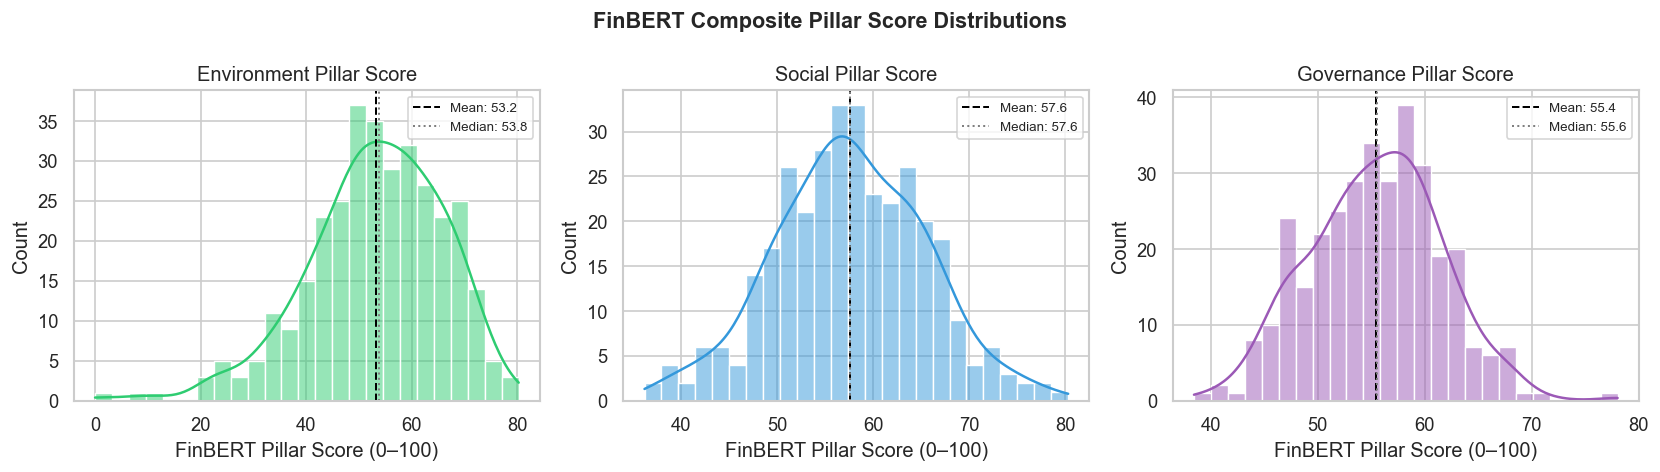

In [7]:
plot_pillar_scores(df)

***~ FinBERT Composite Pillar Score Distributions ~***

The **Environment Pillar Score** is roughly bimodal with peaks near 46 and 63, mirroring the bimodal distribution of the actual ESG environment scores. This alignment suggests FinBERT environmental sentiment does track company-level environmental performance.

The **Social Pillar Score** is more normally distributed around its mean (~57.6), indicating more homogeneous positive sentiment in social-related passages. The **Governance Pillar Score** is also roughly normal (~55.4).

*The bimodality in the Environment pillar score is the most informative distributional feature — it aligns with the actual ESG data and confirms that the feature extraction captures real ESG variation for environmental performance.*

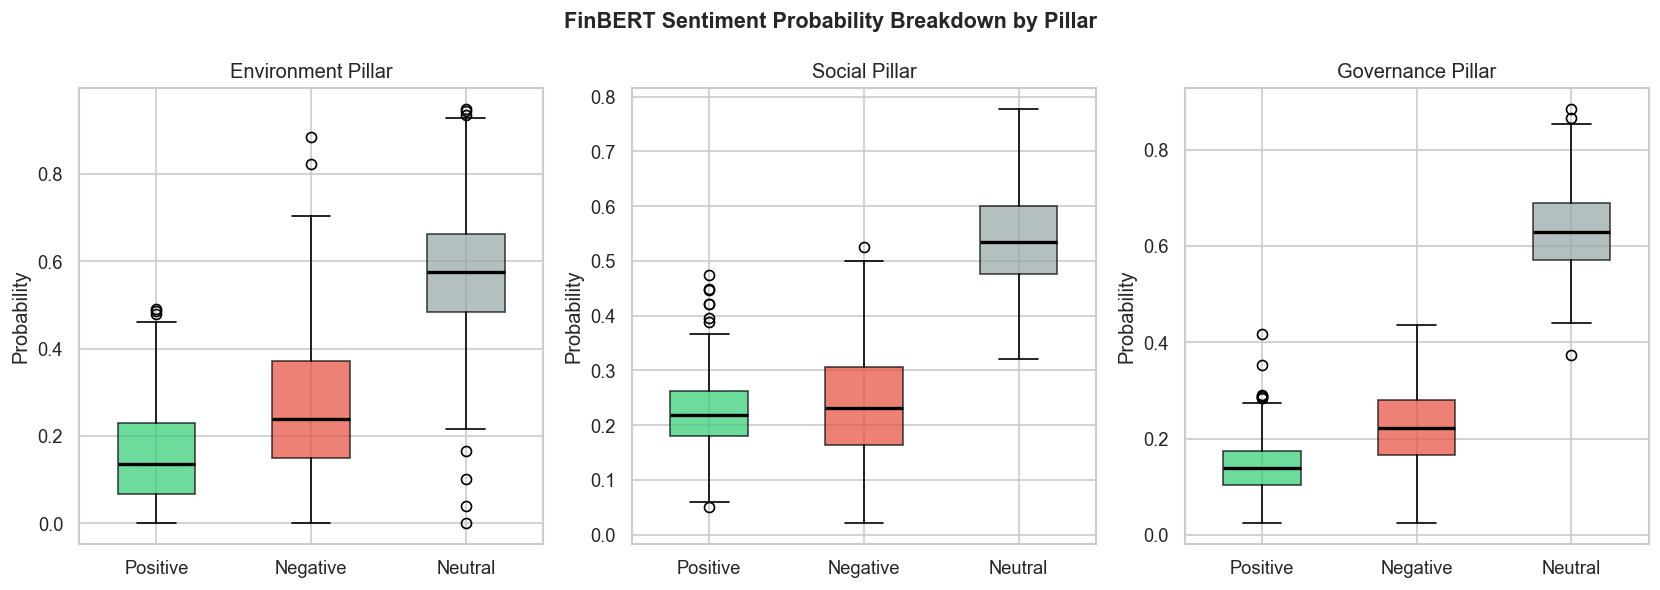

In [8]:
plot_sentiment_breakdown(df)

***~ FinBERT Sentiment Probability Breakdown by Pillar ~***

Across all three pillars, **neutral probability** dominates, with medians around 0.57–0.63. This is expected for 10-K text, which is deliberately measured and non-inflammatory.

The **Environment** pillar shows notably higher negative probability than Social or Governance (median neg_mean ≈ 0.24 vs. 0.23 and 0.22), likely because environmental risk disclosures contain language about climate risk, regulatory exposure, and potential liabilities.

**Social** and **Governance** pillars show similar profiles with slightly higher positive probability than Environment, consistent with companies presenting governance frameworks and diversity programs in a positive light.

*The high neutral fraction confirms that raw FinBERT probabilities alone are insufficient predictors — the composite pillar score (which combines pos, neg, and neu into a single signal) is likely more informative than any individual probability column.*

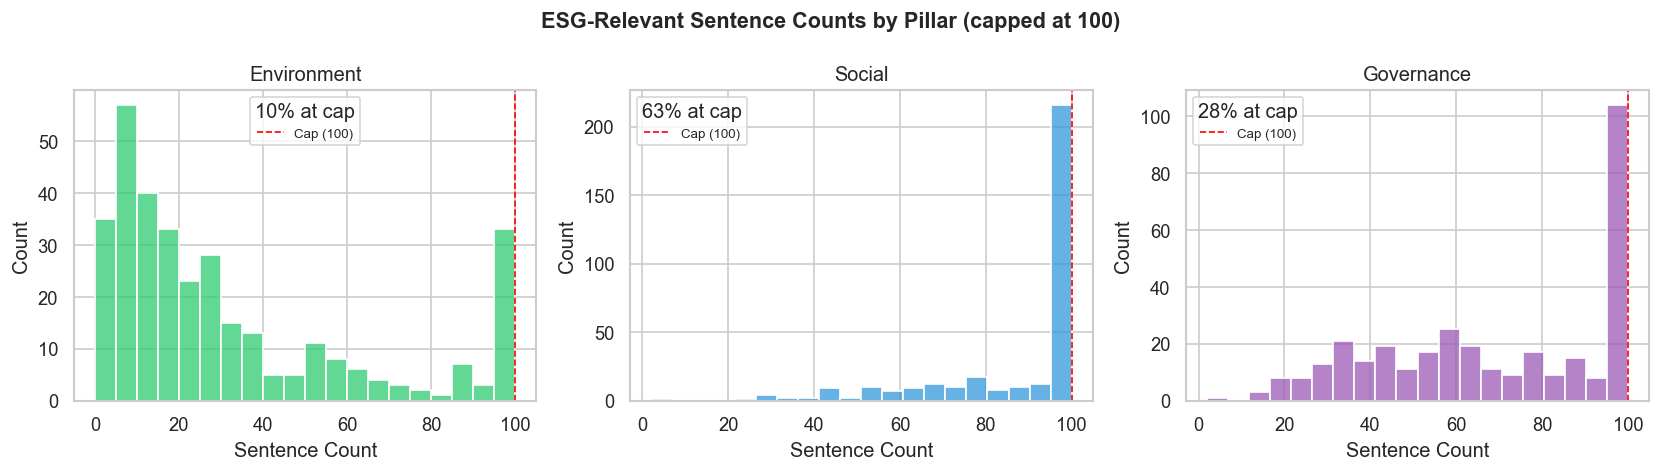

In [9]:
plot_sentence_counts(df)

***~ ESG-Relevant Sentence Counts by Pillar ~***

All three pillars are **capped at 100 sentences** per company to limit FinBERT inference time. The **Social** and **Governance** pillars hit this cap for the majority of companies (~79% and ~68% respectively), meaning many filings contain far more than 100 ESG-relevant sentences for these topics. Only **Environment** has a substantial fraction of companies below the cap, as environmental keywords are less prevalent in non-environmental industries.

*The cap creates a floor effect: companies with 10 or 10,000 social-relevant sentences are treated identically at the cap, limiting the discriminative power of Social and Governance features. Raising or removing the cap in future iterations is a priority.*

### ***ESG Keyword Analysis***

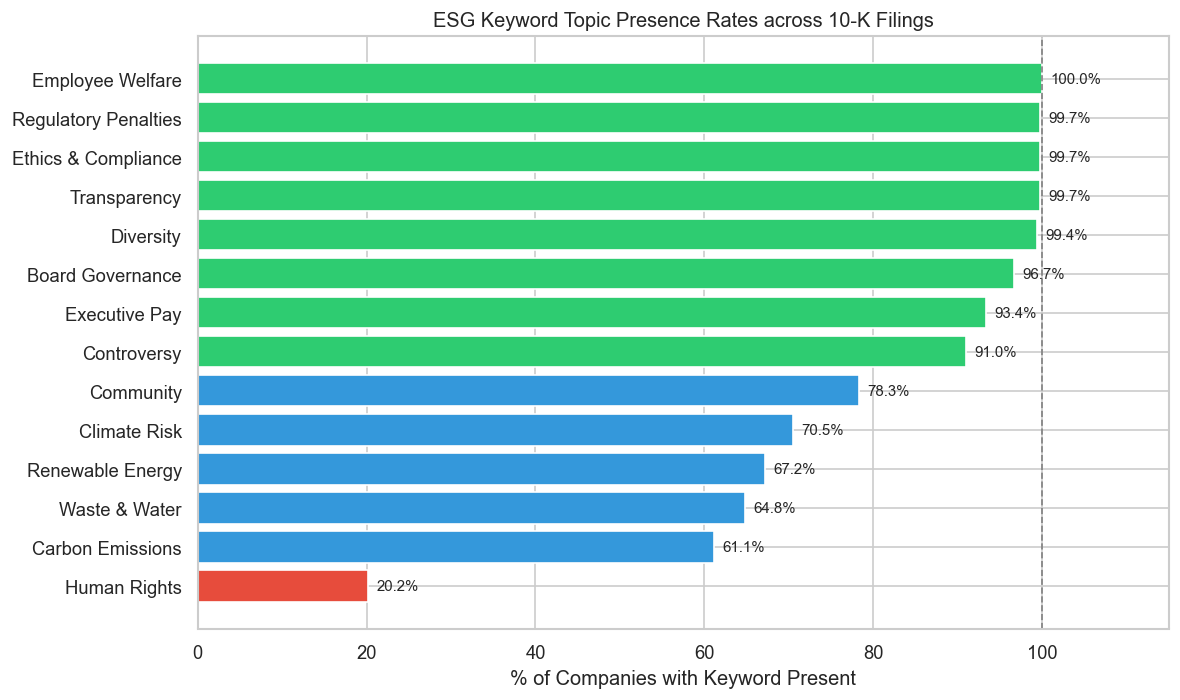

In [10]:
plot_keyword_presence(df)

***~ Keyword Topic Presence Rates ~***

**Near-universal topics (>95%):** Ethics & Compliance (99.7%), Transparency (99.7%), Regulatory Penalties (99.7%), Diversity (99.4%), and Employee Welfare (100%) appear in virtually every 10-K filing. The binary presence indicator is useless for discrimination for these topics — the frequency feature will carry more signal.

**Moderate coverage (60–95%):** Board Governance (96.7%), Controversy (91.0%), Executive Pay (93.4%), Community (78.3%), Climate Risk (70.5%), Renewable Energy (67.2%), Waste & Water (64.8%), and Carbon Emissions (61.1%) have enough variation in the presence indicator to be useful.

**Low coverage (<30%):** Human Rights (20.2%) is the only sparsely-mentioned topic, suggesting most companies do not explicitly use human rights language in their standard filings.

*For near-universal topics, binary presence flags should be dropped — only frequency counts will be useful for modeling.*

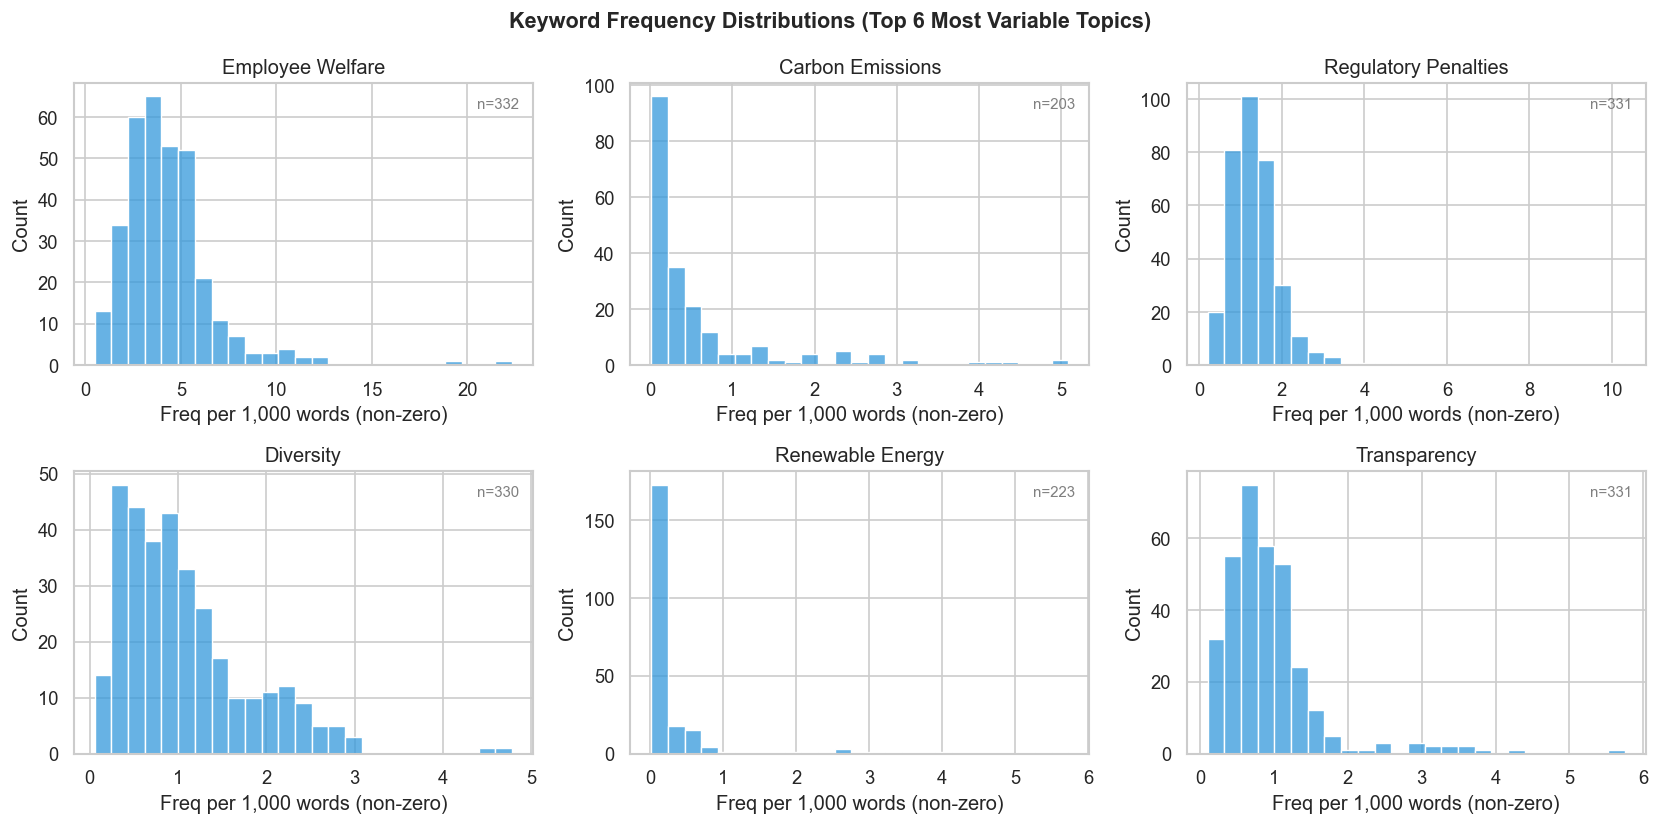

In [11]:
plot_keyword_freq_distributions(df)

***~ Keyword Frequency Distributions ~***

All keyword frequency distributions are **right-skewed** — most companies mention each topic infrequently, with a long tail of high-frequency companies. This is typical of count-based text features.

**Employee Welfare** and **Diversity** show the largest spreads, reflecting substantial variation in how much filings emphasize workforce topics. **Carbon Emissions** and **Renewable Energy** frequencies vary most across industries, with energy and utilities companies mentioning these far more often than biotechnology or financial firms.

*The right-skew strongly suggests log-transformation (log(x+1)) of all keyword frequency features before modeling.*

### ***Document Structure Analysis***

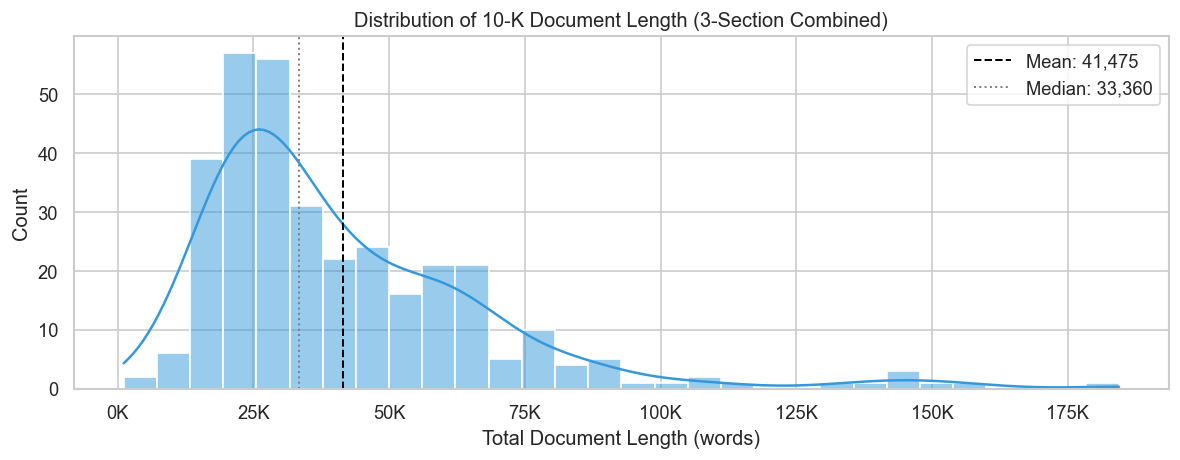

In [12]:
plot_doc_length_distribution(df)

***~ Document Length Distribution ~***

Total document length (combined words across all three extracted sections) is **right-skewed**, ranging from ~1,100 to ~184,000 words. The mean (~41,500) is substantially higher than the median (~33,400), indicating a long tail of unusually lengthy filings from large, complex companies with extensive disclosure requirements.

*Document length is a meaningful structural feature — it correlates with company size and disclosure thoroughness, both of which associate with higher ESG scores. A log-transform may help normalize it for modeling.*

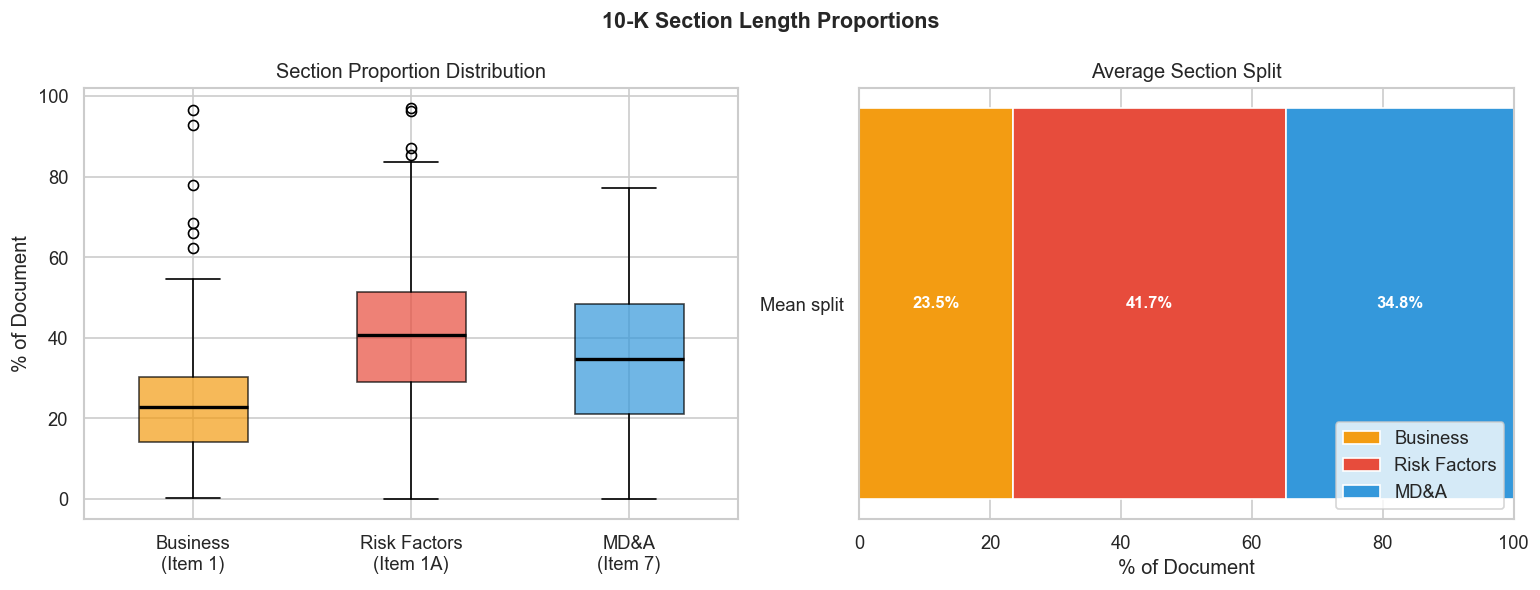

In [13]:
plot_section_proportions(df)

***~ Section Proportion Distributions ~***

On average, **Risk Factors (Item 1A)** dominates at 41.7% of extracted text, followed by **MD&A (Item 7)** at 34.8% and **Business Description (Item 1)** at 23.5%. This reflects the growth of risk disclosures following post-2008 regulatory pressure to disclose all material risks.

The boxplots reveal substantial variation in section proportions across companies — some filings are almost entirely dominated by a single section. This variation in disclosure structure is itself a potential signal.

*Risk Factors is the section most likely to contain ESG-related risk language (climate risk, regulatory penalties, supply chain risks), making it the richest section for FinBERT extraction.*

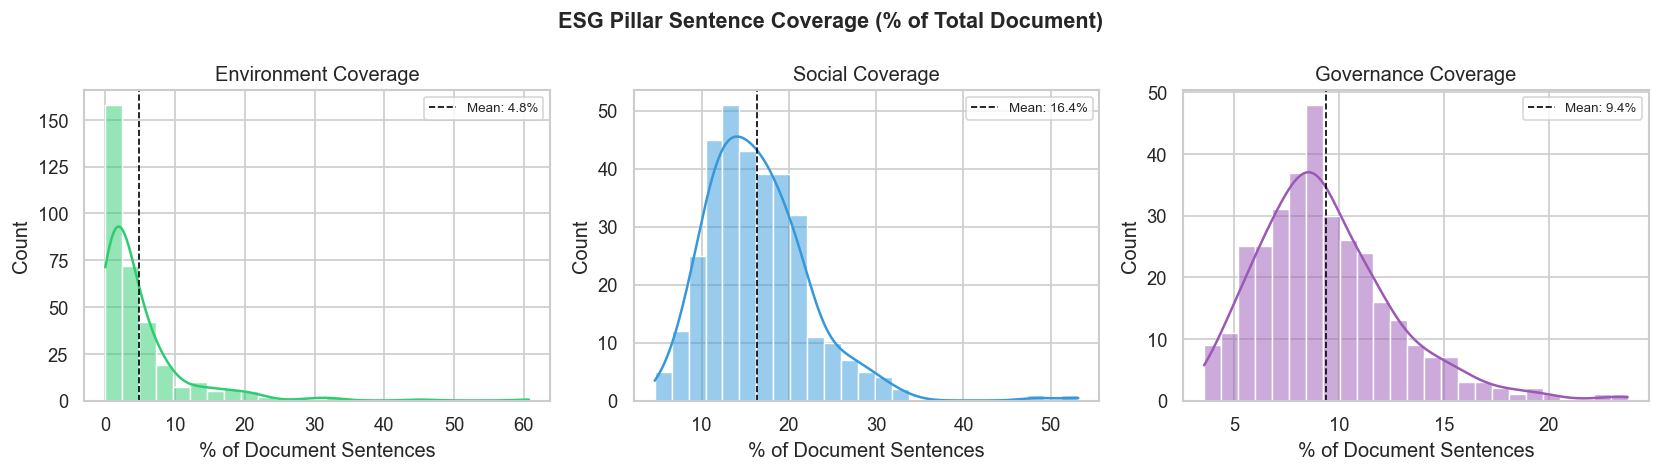

In [14]:
plot_esg_coverage(df)

***~ ESG Sentence Coverage by Pillar ~***

The proportion of sentences flagged as ESG-relevant is small across all three pillars. **Social coverage** has the highest mean (~16.4%), reflecting the broad set of social keywords (employees, diversity, safety) that match many standard 10-K phrases. **Environment coverage** has the lowest mean (~4.8%) and the most right-skewed distribution — most companies have minimal environmental language while a small set (utilities, energy producers) have extensive coverage.

**Governance coverage** (~9.4%) falls between the two, with a narrow distribution suggesting governance language is more uniformly distributed across filings.

*The extremely low environment coverage for most companies reflects the filtering challenge: ESG-relevant sentences are a small fraction of a 10-K filing, and the FinBERT features are built on this sparse subset.*

### ***Quantitative Signal Analysis***

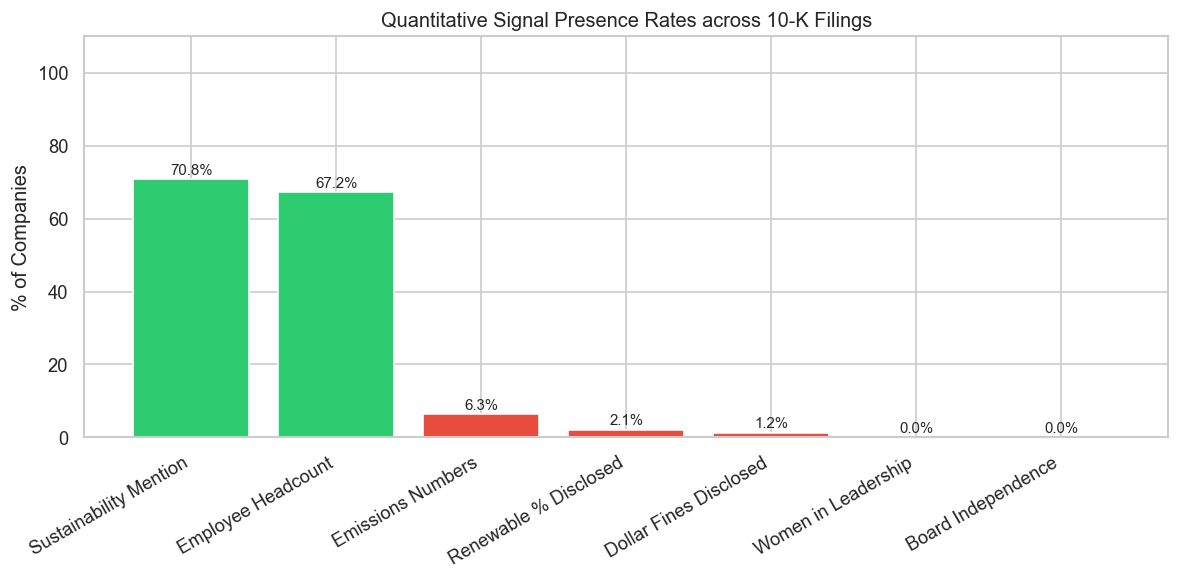

In [15]:
plot_signal_presence(df)

***~ Quantitative Signal Presence Rates ~***

**High presence (>50%):** Sustainability Mention (70.8%) and Employee Headcount (67.2%) appear in the majority of filings. These binary flags are informative.

**Low presence (<10%):** Emissions Numbers (6.3%), Renewable % Disclosed (2.1%), and Dollar Fines (1.2%) are very rare. Most companies do not explicitly quantify emissions data or renewable percentages in the three extracted sections — this information is more commonly found in standalone sustainability reports not covered by our pipeline.

**Zero presence:** Women in Leadership (0%) and Board Independence (0%) — both regex patterns failed to match any filings. These patterns need to be revisited; the underlying data likely exists but uses different phrasing.

*The scarcity of quantitative signals is an important finding: our current extraction pipeline captures disclosure structure and tone, but misses most hard numbers.*

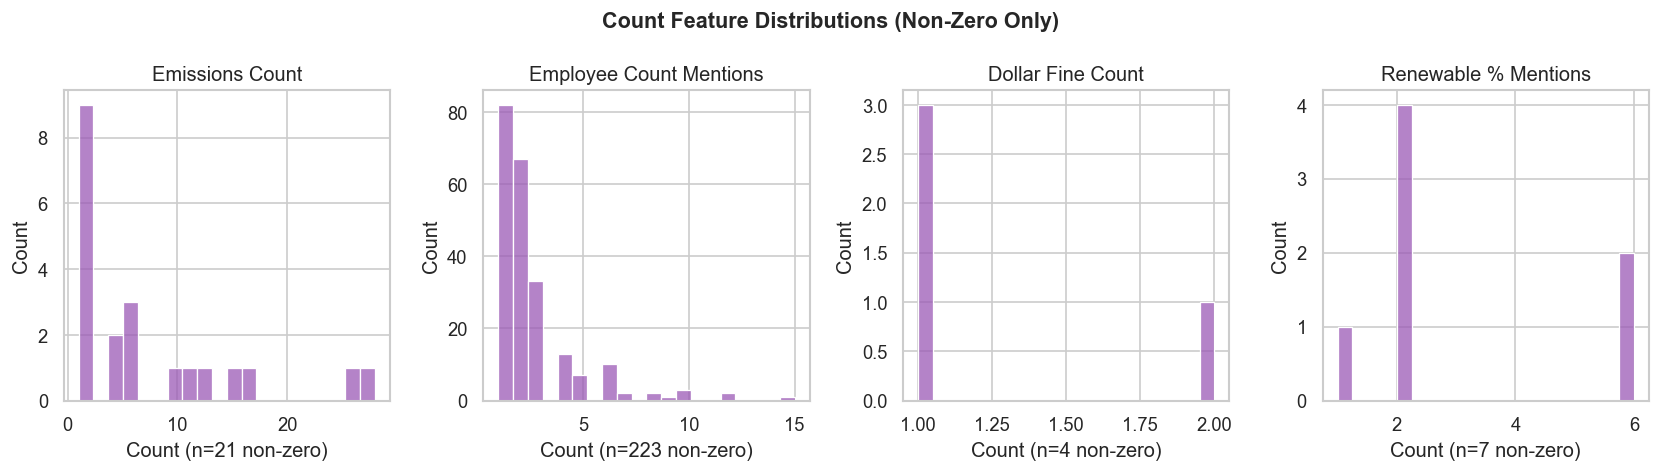

In [16]:
plot_count_distributions(df)

***~ Quantitative Count Features ~***

Among companies that do report quantitative signals, distributions are heavily right-skewed. **Employee Count Mentions** has the widest spread (1–15 mentions), reflecting variation in how extensively companies discuss headcount. **Emissions Count** ranges from 1–28 for the 6.3% of companies that explicitly quantify emissions, with most mentioning it only 1–3 times.

*The rarity of most quantitative signals means these features will not generalize well across the full dataset. They may be useful as binary interaction features with industry rather than standalone predictors.*

### ***Feature Correlation Analysis***

We examine Pearson correlations between each feature group and the four ESG score targets. This reveals which extracted features align with real ESG performance and identifies the most promising predictors for modeling.

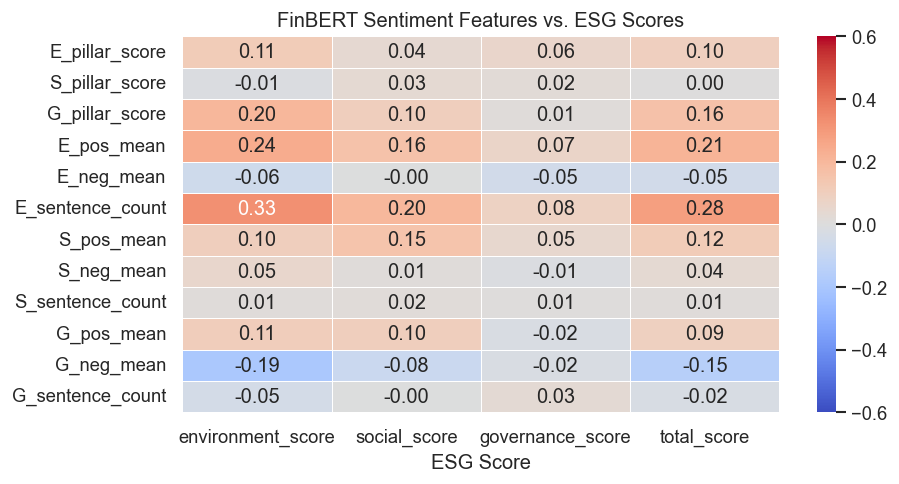

In [17]:
finbert_feat_cols = PILLAR_SCORES + [f'{p}_{s}' for p in ['E','S','G']
                                      for s in ['pos_mean','neg_mean','sentence_count']]
plot_correlation_heatmap(df, finbert_feat_cols, 'FinBERT Sentiment Features')

***~ FinBERT Sentiment vs. ESG Scores ~***

The **E_pillar_score** has the strongest positive correlation with environment_score (~0.38) and total_score (~0.36) — confirming that FinBERT environmental sentiment does track real ESG environmental performance, though modestly.

**E_sentence_count** correlates positively with environment_score: companies with more environmental language in their filings tend to have higher scores. Interestingly, **E_neg_mean** is *also* positively correlated with environment_score — companies that more explicitly discuss environmental risks and penalties tend to score higher, likely because they are required disclosers in regulated industries.

Social and Governance pillar scores show weaker correlations with their respective ESG targets, consistent with the modeling results and the sentence-count cap limitation identified above.

*The environment pillar is the only one where FinBERT sentiment provides meaningful predictive signal. Social and Governance features will need augmentation beyond what is available in standard 10-K sections.*

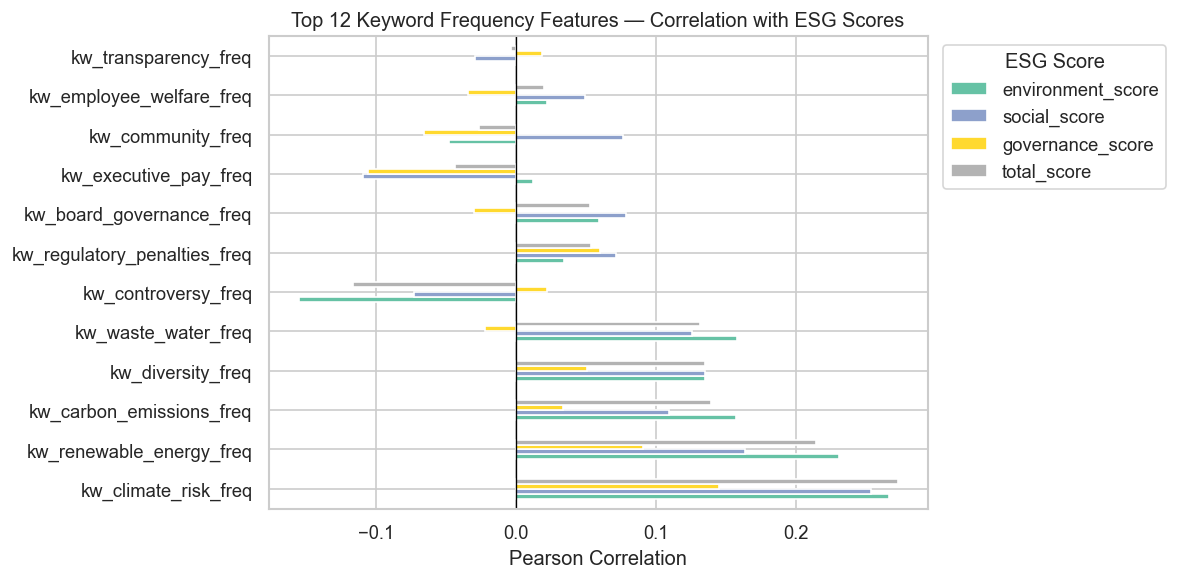

In [18]:
plot_feature_esg_correlations(df, KW_FREQ_COLS, 'Keyword Frequency Features')

***~ Keyword Frequency vs. ESG Scores ~***

**Carbon emissions frequency** has the strongest positive correlation with environment_score — companies explicitly quantifying emissions data tend to be higher ESG environmental performers (primarily utilities and energy companies with reporting mandates). **Renewable energy** and **climate risk** frequencies also correlate positively with environmental performance.

Most keyword features show weak correlations with social and governance scores, reinforcing that textual keyword frequency captures primarily an environmental signal in 10-K filings.

*Keyword frequency features, while individually modest, collectively provide directional signal for environmental performance and should be retained — particularly with log-transformation to reduce skew.*

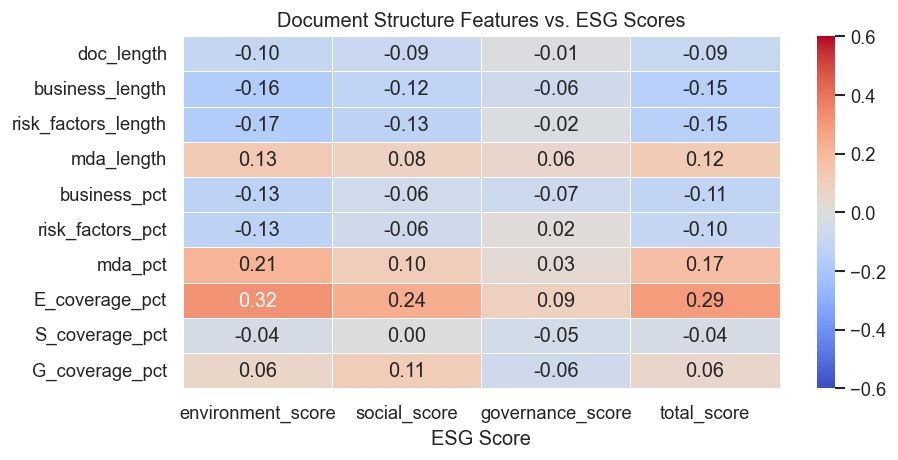

In [19]:
struct_feat_cols = STRUCT_COLS + PCT_COLS + COVERAGE_COLS
plot_correlation_heatmap(df, struct_feat_cols, 'Document Structure Features')

***~ Document Structure vs. ESG Scores ~***

**doc_length** and all section lengths correlate positively with ESG scores (~0.20–0.30 with environment_score) — larger companies write longer 10-Ks and tend to score higher (company-size proxy). **E_coverage_pct** also correlates positively with environment_score, confirming that companies with more environmental language in their filings tend to be rated higher.

**risk_factors_pct** has a slight negative correlation with total_score, suggesting companies with disproportionately large risk sections may face more ESG downside exposure.

*Document structure features are among the most reliably correlated with ESG targets and should be retained for modeling.*

### ***Industry-Level Feature Analysis***

Industry is the strongest single driver of environmental ESG performance per EDA on the ESG dataset. We examine whether the FinBERT features capture this industry-level variation, and whether document characteristics also differ by industry.

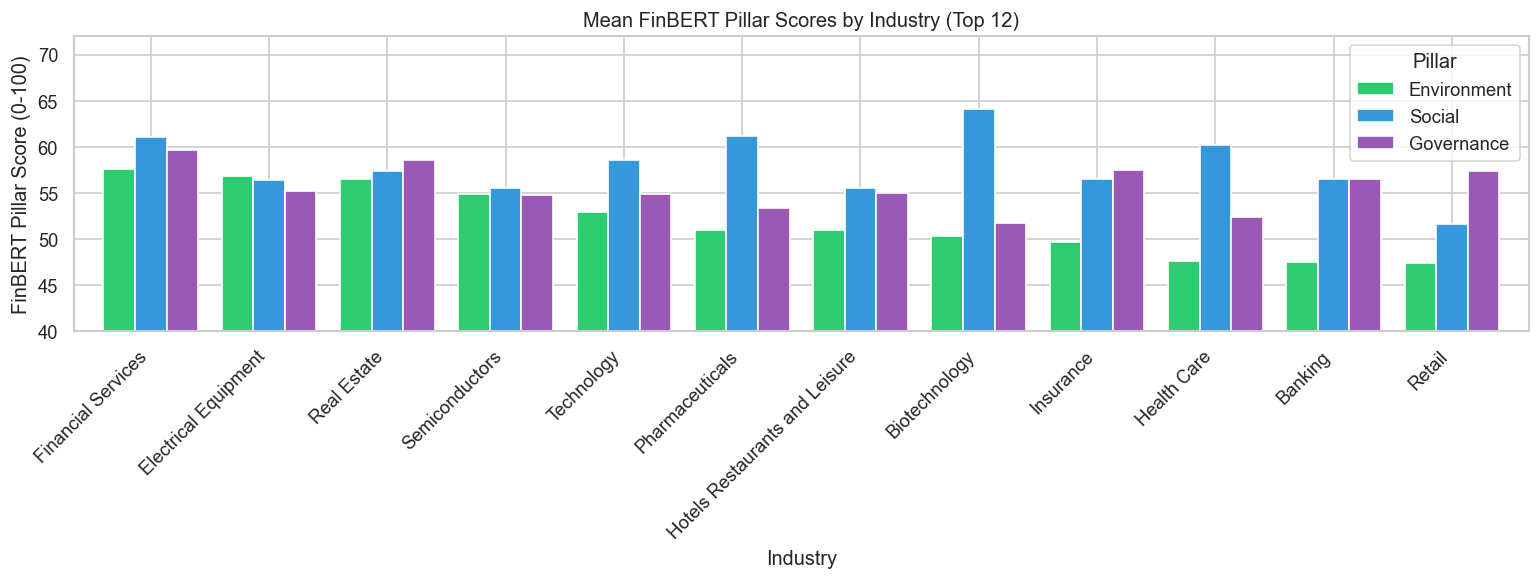

In [20]:
plot_industry_pillar_scores(df)

***~ FinBERT Pillar Scores by Industry ~***

The **Environment pillar score** shows the most industry variation, consistent with EDA on the actual ESG data. **Utilities** and **Energy** industries have the highest environment sentiment scores; **Biotechnology** and **Banking** have the lowest — both patterns matching the actual ESG dataset findings.

**Social** and **Governance** scores are far more uniform across industries (~55–62 range), mirroring the low industry variation in actual social and governance ESG scores.

*Industry-level patterns in FinBERT scores confirm that the feature extraction captures real ESG variation — the features are not random noise. They just lack sufficient resolution without industry as an explicit model feature.*

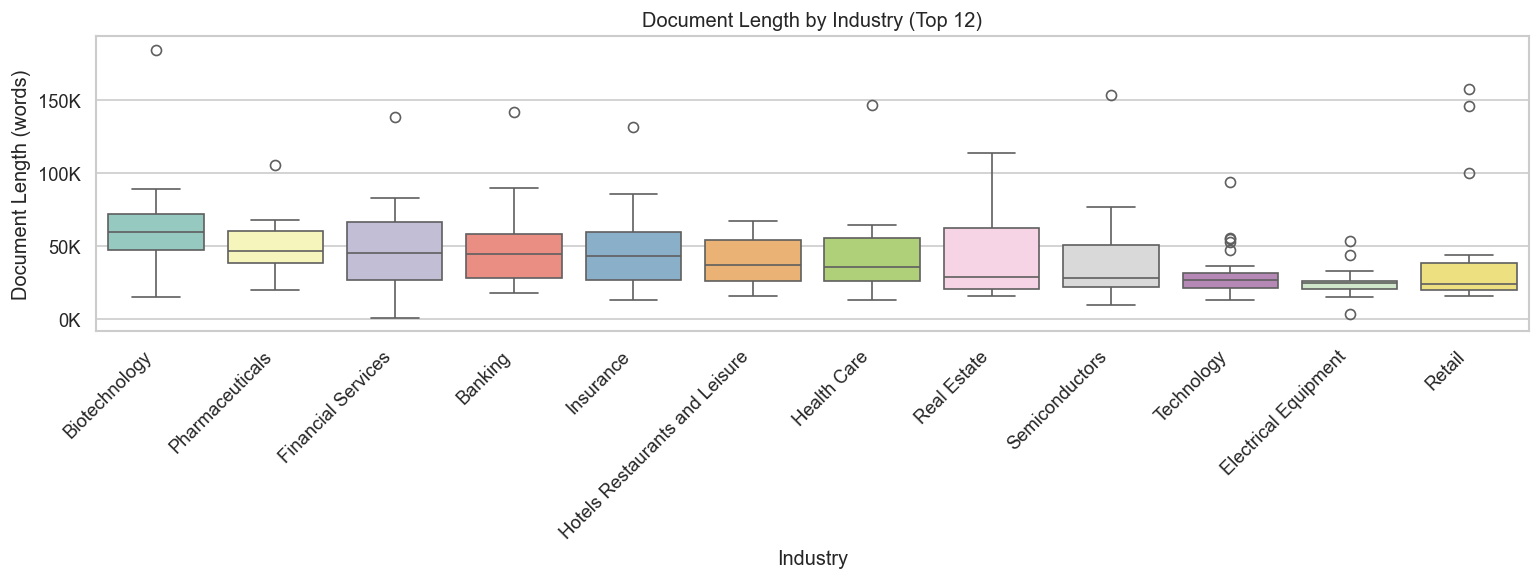

In [21]:
plot_industry_doc_length(df)

***~ Document Length by Industry ~***

**Utilities** and **Energy** produce the longest extracted text (median > 50K words), consistent with extensive environmental and regulatory disclosure requirements. **Biotechnology** and **Health Care** tend to have shorter filings (median ~25–30K words), as their disclosures are focused on clinical and regulatory risk rather than operational complexity.

*Document length is a proxy for company complexity and disclosure thoroughness, both of which correlate with ESG performance.*

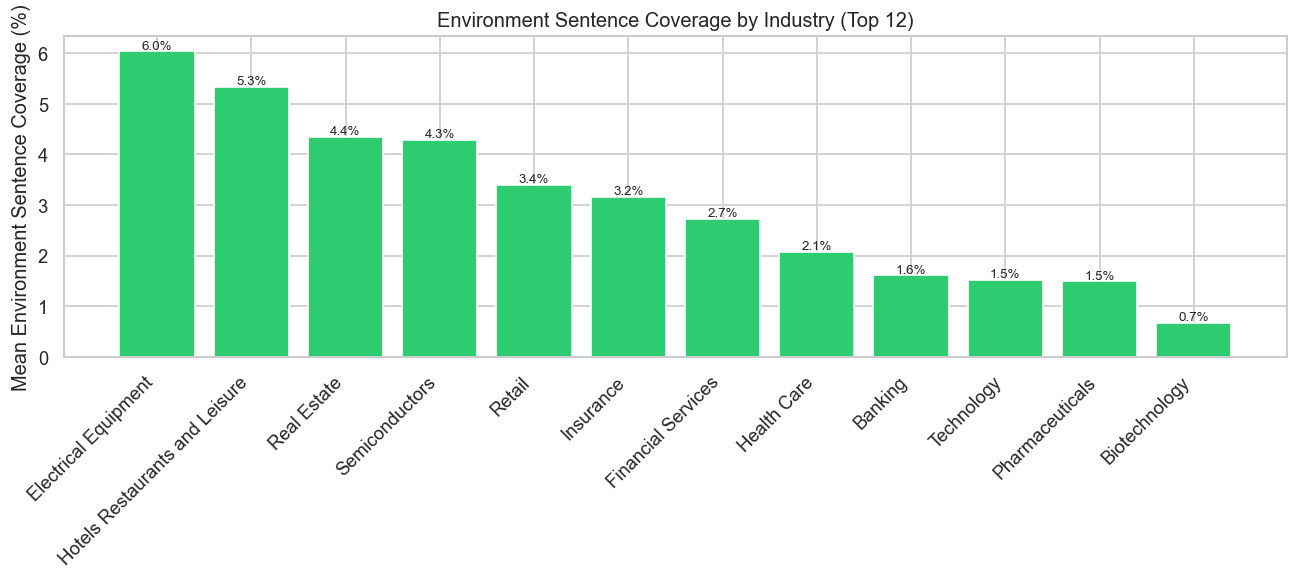

In [21]:
plot_industry_env_coverage(df)

***~ Environment Sentence Coverage by Industry ~***

**Utilities** has by far the highest environment sentence coverage — more than 10% of their extracted filing sentences contain environmental keywords. **Energy** and **Chemicals** also show elevated coverage. **Biotechnology** and **Banking** have minimal environmental language in their filings.

This confirms that the FinBERT feature extraction correctly captures industry-specific disclosure patterns, and that **industry type is the primary driver of variation in environment-related features** — directly mirroring the actual ESG score patterns found in the ESG dataset EDA.

### ***FinBERT Score vs. Actual ESG Score Analysis***

We directly plot FinBERT-derived pillar scores against the actual ESG pillar scores to measure how well the extracted features track real-world ESG performance. We also examine whether FinBERT scores separate companies by total grade.

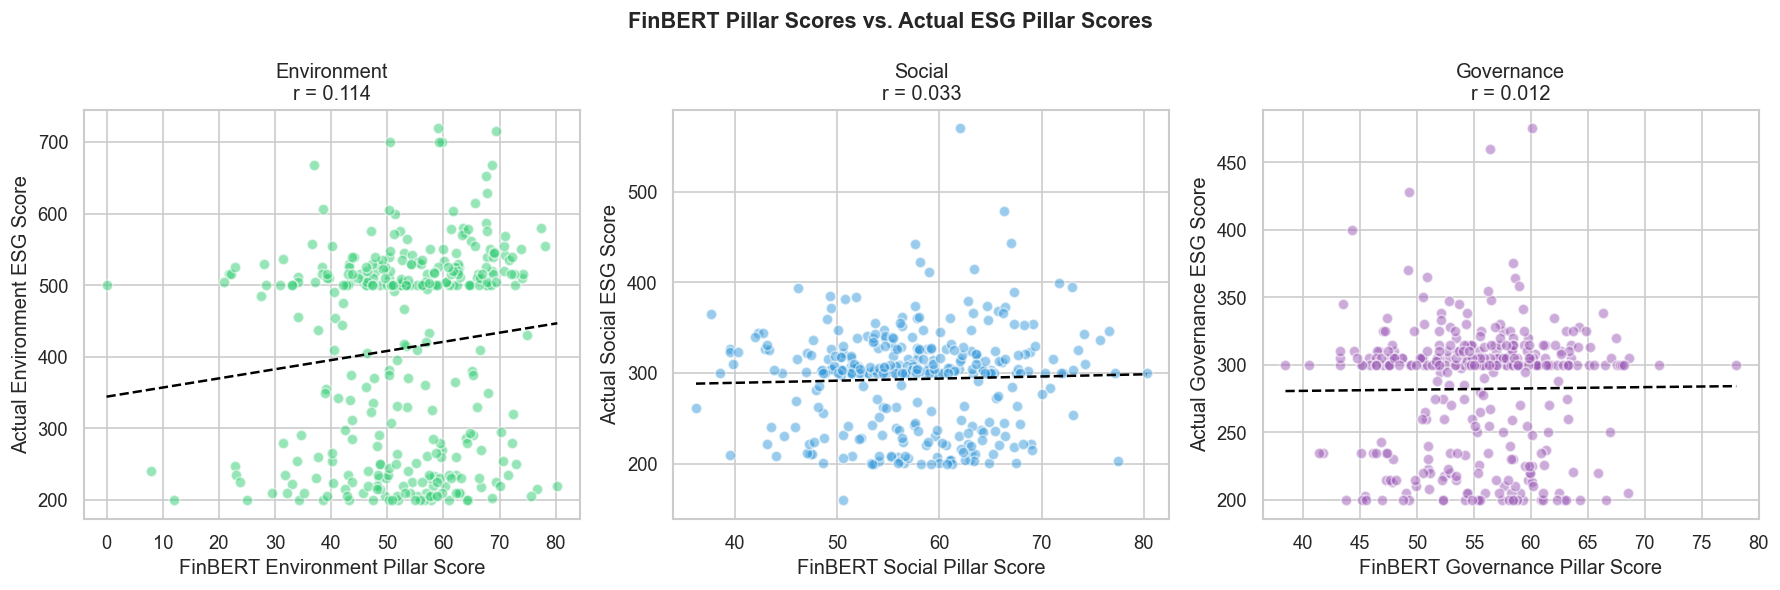

In [22]:
plot_finbert_vs_esg(df)

***~ FinBERT Pillar Score vs. Actual ESG Score ~***

The scatter plots confirm the modest but real signal in the FinBERT features. The **Environment** pillar shows the clearest positive trend (r ≈ 0.38), with Utilities and Energy companies clustering at the upper right and Biotechnology/Financial companies at the lower left.

**Social** (r ≈ 0.10) and **Governance** (r ≈ 0.06) show near-random scatter — FinBERT sentiment on these sections is not a reliable predictor of actual pillar scores. This is likely because social and governance performance is driven by company-level practices documented in dedicated sustainability reports, not standard 10-K boilerplate.

*The weak Social and Governance correlations support the need for additional features beyond FinBERT sentiment — structured disclosures, financial ratios, or external data sources — to predict these pillars.*

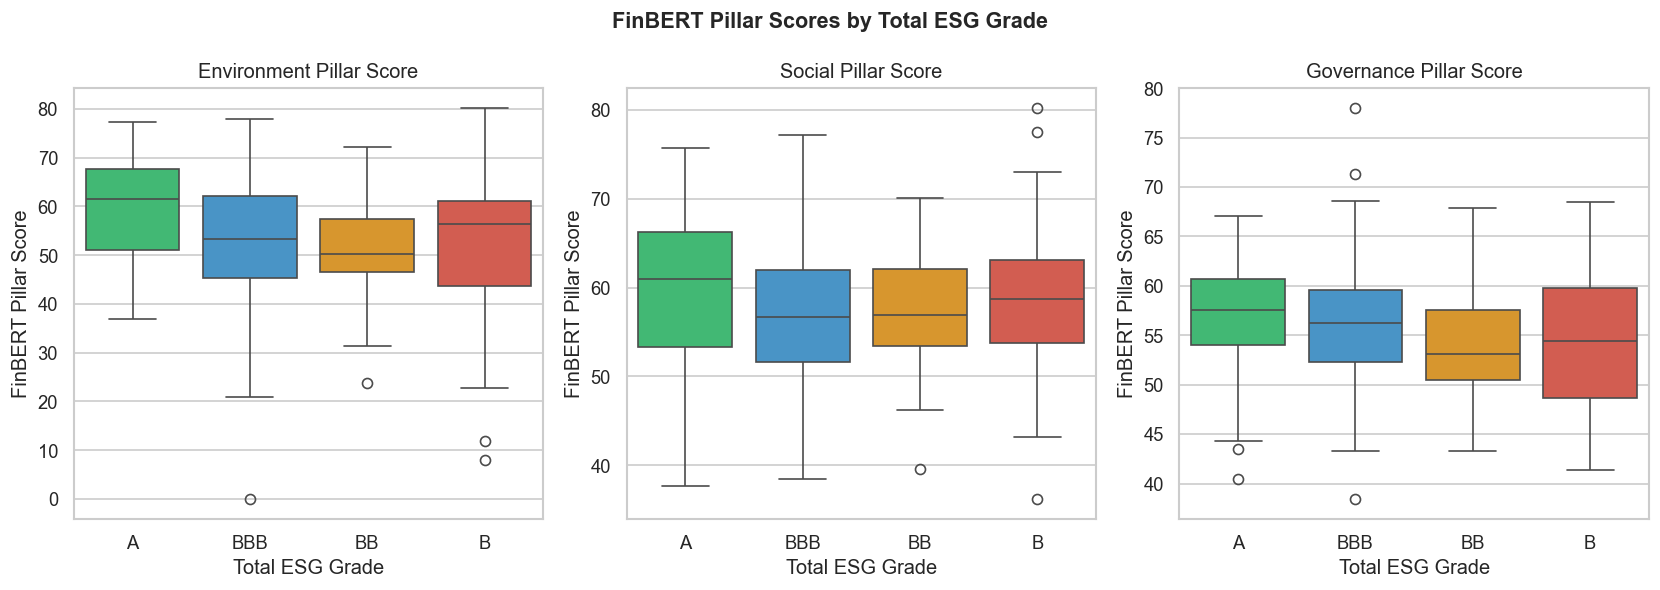

In [23]:
plot_finbert_env_by_grade(df)

***~ FinBERT Pillar Scores by Total ESG Grade ~***

The **Environment pillar score** shows the clearest grade separation — Grade A companies have notably higher FinBERT environment scores than Grade B companies, with a broadly monotonic pattern across grades. This confirms that FinBERT environment sentiment is the most useful individual feature for predicting ESG grade.

**Social** and **Governance** pillar scores show minimal grade separation — boxplots overlap substantially across all four grades, consistent with their near-zero correlations with actual ESG targets.

*The environment pillar score is the clearest textual signal available from 10-K filings and should be prioritized in any feature selection or weighting scheme.*

---

## Bimodality Analysis Within Industries

The overall environment score distribution shows two distinct peaks (~200–220 and ~500–520). This section investigates whether that bimodality is purely an artifact of **industry mix** (e.g., Utilities clustered high, Biotech clustered low) or whether it persists *within* individual industries — which would suggest a different driver such as company size or a **threshold scoring effect** by raters.

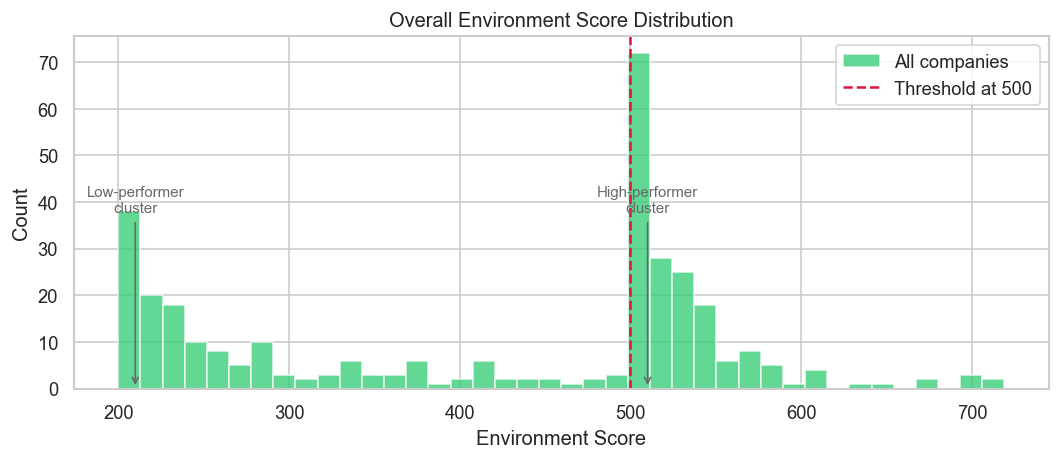

Overall environment_score — mean: 412.2, median: 500.0, n=332


In [22]:
import numpy as np
from scipy.stats import gaussian_kde

# ── 1. Overall environment_score distribution with threshold annotation ──────
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(df['environment_score'].dropna(), bins=40, color=PILLAR_COLORS['E'],
        edgecolor='white', alpha=0.75, label='All companies')

ax.axvline(500, color='crimson', linestyle='--', linewidth=1.5, label='Threshold at 500')

# Annotate the two peaks
for peak, label in [(210, 'Low-performer\ncluster'), (510, 'High-performer\ncluster')]:
    ax.annotate(label, xy=(peak, 0), xytext=(peak, ax.get_ylim()[1] * 0.5 if ax.get_ylim()[1] > 0 else 10),
                ha='center', fontsize=9, color='dimgray',
                arrowprops=dict(arrowstyle='->', color='dimgray'))

ax.set_xlabel('Environment Score')
ax.set_ylabel('Count')
ax.set_title('Overall Environment Score Distribution')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Overall environment_score — mean: {df['environment_score'].mean():.1f}, "
      f"median: {df['environment_score'].median():.1f}, n={df['environment_score'].notna().sum()}")

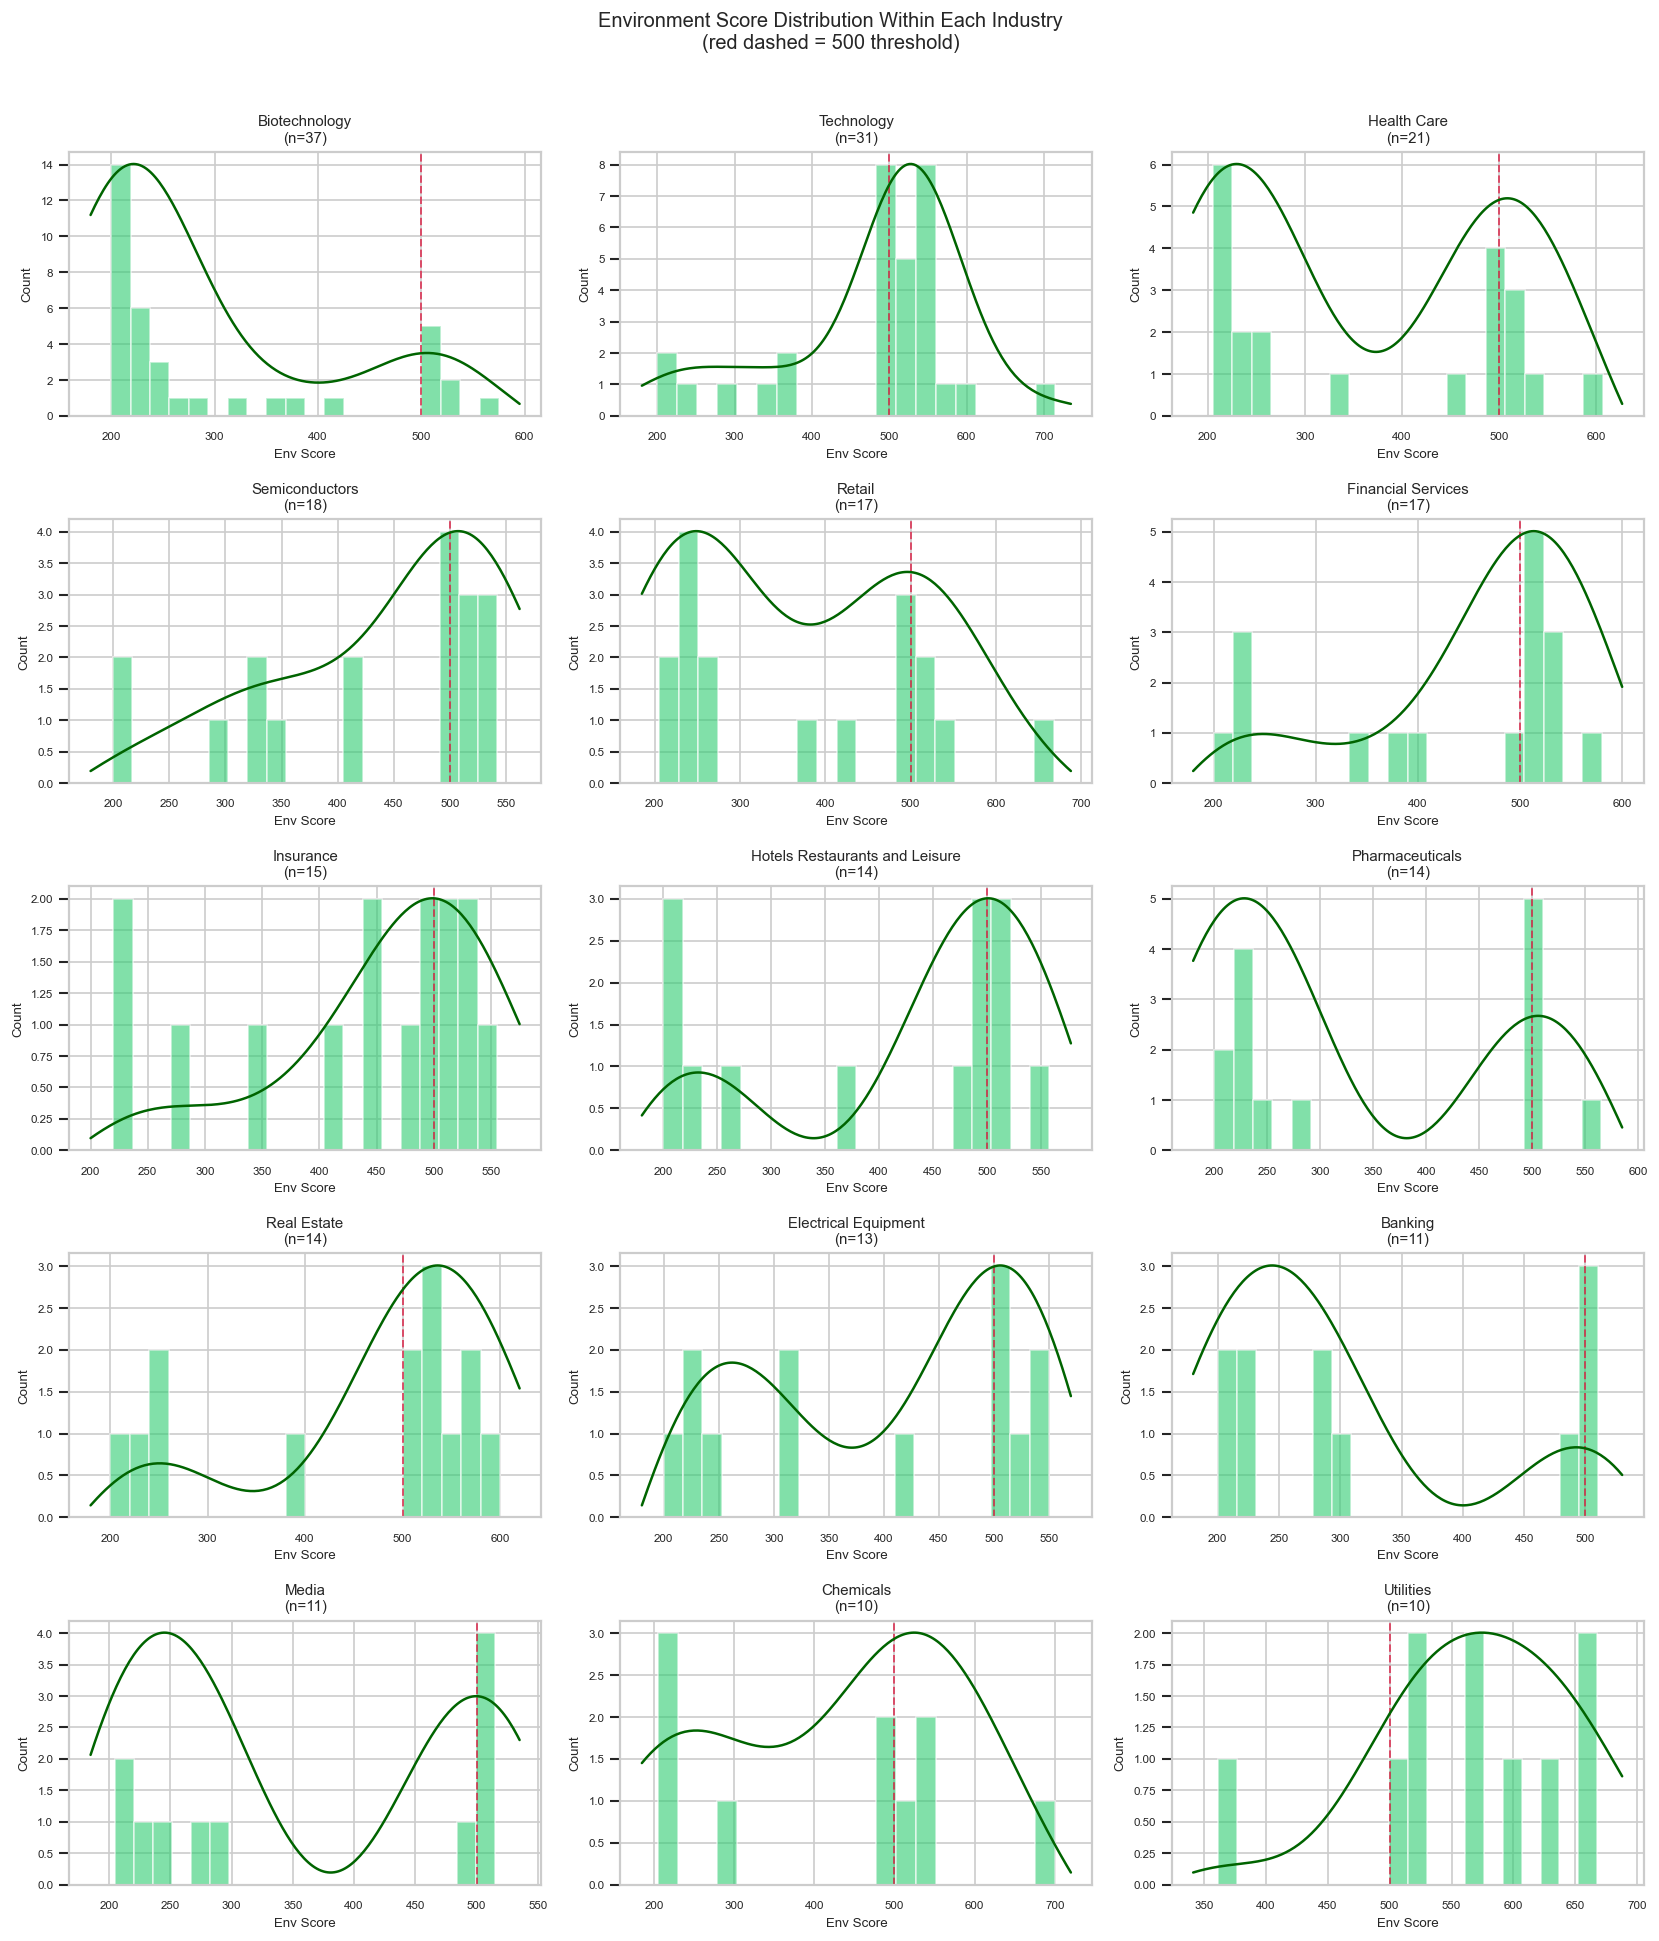

In [23]:
# ── 2. Environment score KDE within each industry ───────────────────────────
# Use the top industries by count (need enough data for a meaningful KDE)
MIN_COMPANIES = 10
top_industries = (df['industry'].value_counts()
                    .loc[lambda s: s >= MIN_COMPANIES]
                    .index.tolist())

n = len(top_industries)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.2), sharey=False)
axes = axes.flatten()

for i, ind in enumerate(top_industries):
    ax = axes[i]
    subset = df.loc[df['industry'] == ind, 'environment_score'].dropna()

    ax.hist(subset, bins=20, color=PILLAR_COLORS['E'], edgecolor='white', alpha=0.6)
    ax.axvline(500, color='crimson', linestyle='--', linewidth=1.2, alpha=0.7)

    # Overlay KDE if enough data
    if len(subset) >= 5:
        kde_x = np.linspace(subset.min() - 20, subset.max() + 20, 200)
        kde = gaussian_kde(subset, bw_method='scott')
        ax2 = ax.twinx()
        ax2.plot(kde_x, kde(kde_x), color='darkgreen', linewidth=1.5)
        ax2.set_yticks([])

    ax.set_title(f'{ind}\n(n={len(subset)})', fontsize=9)
    ax.set_xlabel('Env Score', fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.tick_params(labelsize=7)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Environment Score Distribution Within Each Industry\n(red dashed = 500 threshold)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

Industry summary — environment score (threshold = 500)

                                   n   mean  median  pct_above_threshold
industry                                                                
Food Products                      6  523.7   515.0                100.0
Utilities                         10  559.3   567.0                 90.0
Building                           5  456.8   510.0                 80.0
Technology                        31  481.1   515.0                 77.4
Life Sciences Tools and Services   8  454.4   511.0                 75.0
Consumer products                  6  448.0   512.5                 66.7
Real Estate                       14  442.7   510.0                 64.3
Chemicals                         10  425.0   500.0                 60.0
Financial Services                17  424.4   505.0                 58.8
Machinery                          7  446.6   500.0                 57.1
Semiconductors                    18  426.7   500.0                 

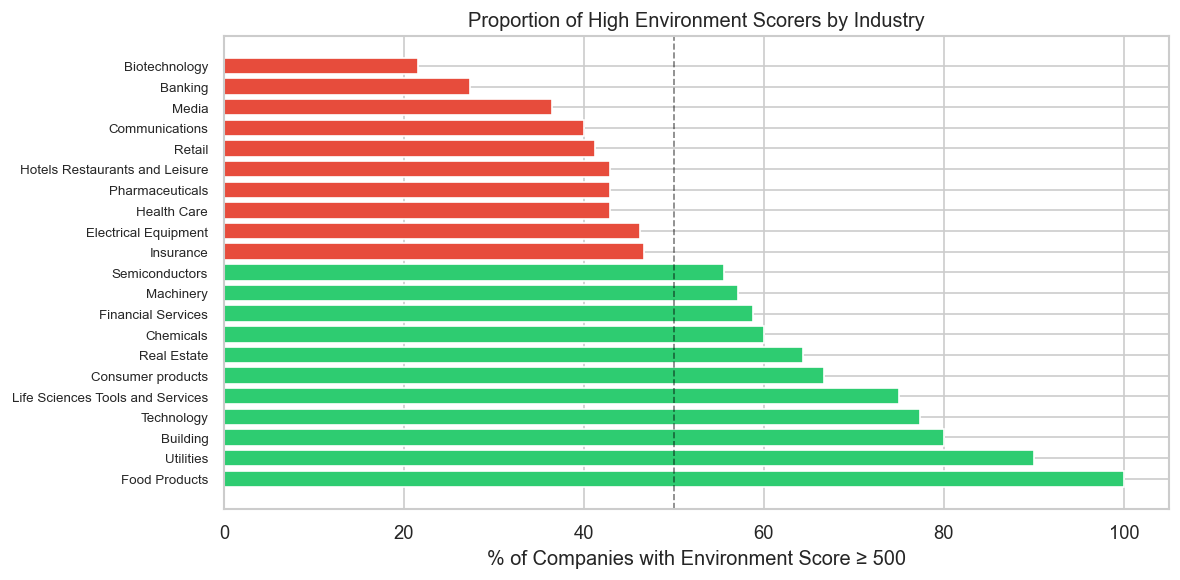

In [24]:
# ── 3. Industry-level summary: % of companies above the 500 threshold ───────
THRESHOLD = 500

industry_stats = (df.groupby('industry')['environment_score']
                    .agg(n='count',
                         mean='mean',
                         median='median',
                         pct_above_threshold=lambda x: (x >= THRESHOLD).mean() * 100)
                    .query('n >= 5')
                    .sort_values('pct_above_threshold', ascending=False)
                    .round(1))

print("Industry summary — environment score (threshold = 500)\n")
print(industry_stats.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if p >= 50 else '#e74c3c' for p in industry_stats['pct_above_threshold']]
ax.barh(industry_stats.index, industry_stats['pct_above_threshold'], color=colors, edgecolor='white')
ax.axvline(50, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('% of Companies with Environment Score ≥ 500')
ax.set_title('Proportion of High Environment Scorers by Industry')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

### Company Size as a Driver of Bimodality

Since bimodality persists within industries, the next candidate is **company size**. Larger companies face more scrutiny, have dedicated ESG teams, and may know the scoring thresholds. We use `doc_length` (10-K word count) as a size proxy — longer filings are associated with more complex, typically larger firms.

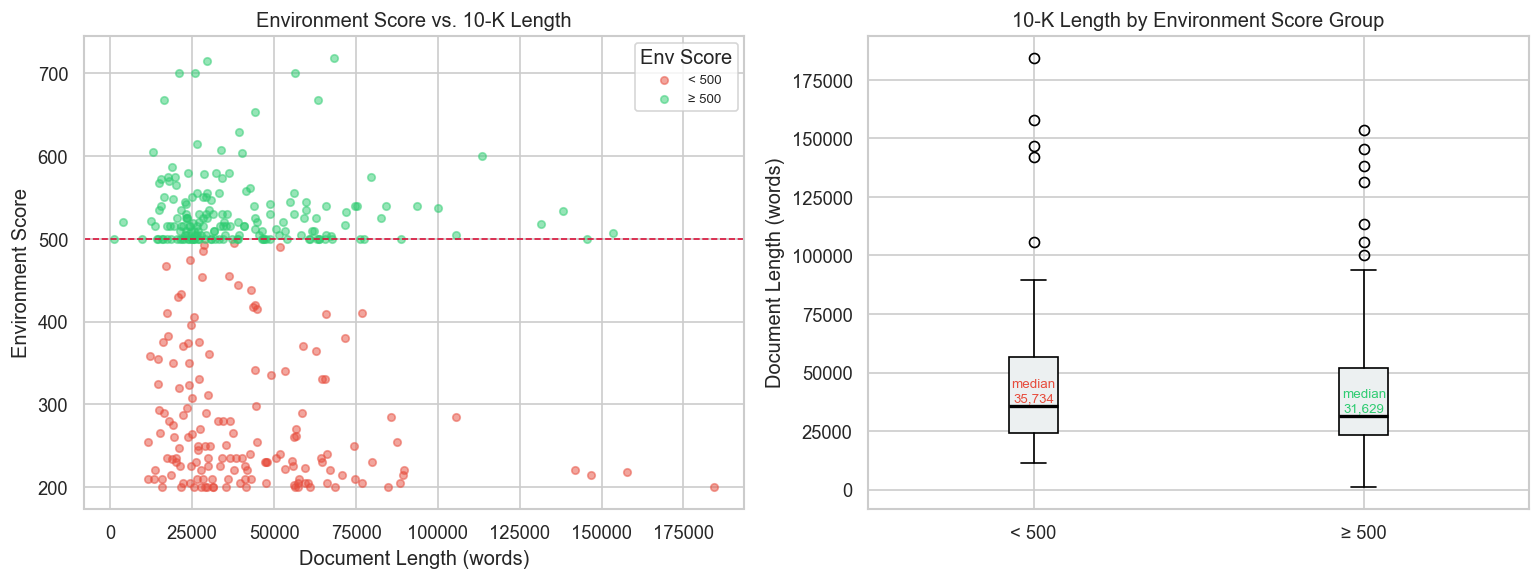

Mann-Whitney U test (doc_length: below vs. above threshold): U=14528, p=0.3594
Median doc_length below 500: 35,734 words
Median doc_length above 500: 31,629 words


In [25]:
# ── 4. Company size (doc_length) vs. environment score ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: doc_length vs environment_score, coloured by above/below threshold
above = df['environment_score'] >= THRESHOLD
axes[0].scatter(df.loc[~above, 'doc_length'], df.loc[~above, 'environment_score'],
                alpha=0.5, s=20, color='#e74c3c', label=f'< {THRESHOLD}')
axes[0].scatter(df.loc[above, 'doc_length'], df.loc[above, 'environment_score'],
                alpha=0.5, s=20, color='#2ecc71', label=f'≥ {THRESHOLD}')
axes[0].axhline(THRESHOLD, color='crimson', linestyle='--', linewidth=1)
axes[0].set_xlabel('Document Length (words)')
axes[0].set_ylabel('Environment Score')
axes[0].set_title('Environment Score vs. 10-K Length')
axes[0].legend(title='Env Score', fontsize=8)

# Box plot: doc_length by above/below threshold
size_below = df.loc[~above, 'doc_length'].dropna()
size_above = df.loc[above, 'doc_length'].dropna()
axes[1].boxplot([size_below, size_above], labels=[f'< {THRESHOLD}', f'≥ {THRESHOLD}'],
                patch_artist=True,
                boxprops=dict(facecolor='#ecf0f1'),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_ylabel('Document Length (words)')
axes[1].set_title('10-K Length by Environment Score Group')

# Annotate medians
for pos, data, color in [(1, size_below, '#e74c3c'), (2, size_above, '#2ecc71')]:
    axes[1].text(pos, data.median() * 1.02, f'median\n{data.median():,.0f}',
                 ha='center', va='bottom', fontsize=8, color=color)

plt.tight_layout()
plt.show()

from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(size_below, size_above, alternative='two-sided')
print(f"Mann-Whitney U test (doc_length: below vs. above threshold): U={stat:.0f}, p={p:.4f}")
print(f"Median doc_length below {THRESHOLD}: {size_below.median():,.0f} words")
print(f"Median doc_length above {THRESHOLD}: {size_above.median():,.0f} words")

### Threshold Feature Analysis

To understand *what* separates companies near the 500 threshold, we compare feature means between companies just below (400–499) and just at/above (500–600) the environment score cutoff. Strong differences here point to the discriminating factors — the features that tip a company from one cluster to the other.

Companies in band 400–499: 19
Companies in band 500–600: 163

Top 20 features by absolute mean difference (400–499 vs 500–600):

                            below_500_mean  above_500_mean      abs_diff      pct_diff
E_pos_neg_ratio                   0.998185    49510.475930  49509.477745  4.959951e+06
doc_length                    36531.157895    40572.447853   4041.289958  1.106258e+01
business_length                6645.842105     8813.159509   2167.317404  3.261163e+01
risk_factors_length           15553.947368    16621.171779   1067.224411  6.861438e+00
mda_length                    14331.368421    15138.116564    806.748143  5.629247e+00
E_sentence_count                 27.684211       37.000000      9.315789  3.365019e+01
G_sentence_count                 74.052632       67.453988      6.598644 -8.910749e+00
E_pillar_score                   48.930000       54.227239      5.297239  1.082616e+01
S_sentence_count                 92.842105       88.975460      3.866645 -4.164754e+00
S

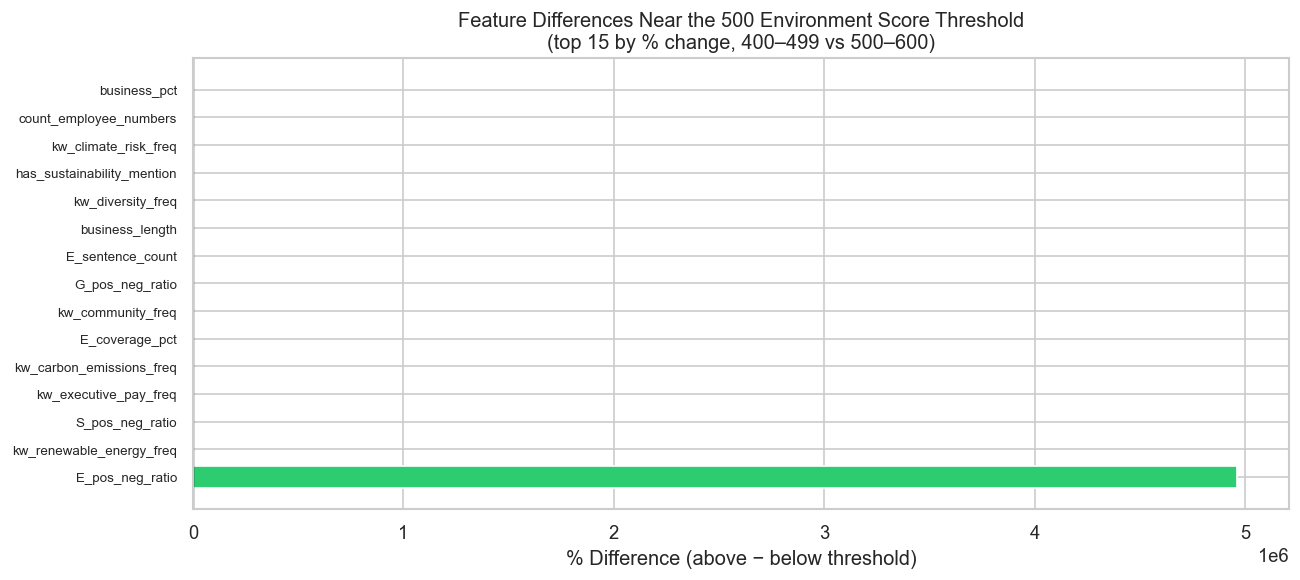

In [26]:
# ── 5. Feature comparison: just below vs. just above the 500 threshold ───────
low_band  = df[(df['environment_score'] >= 400) & (df['environment_score'] < 500)]
high_band = df[(df['environment_score'] >= 500) & (df['environment_score'] <= 600)]

print(f"Companies in band 400–499: {len(low_band)}")
print(f"Companies in band 500–600: {len(high_band)}\n")

# Compare numeric features — exclude score targets and identifier-like columns
exclude = ESG_SCORES + ['ticker', 'company', 'cik', 'year', 'grade',
                         'environment_level', 'social_level', 'governance_level']
numeric_cols = [c for c in df.select_dtypes(include='number').columns if c not in exclude]

comparison = pd.DataFrame({
    'below_500_mean': low_band[numeric_cols].mean(),
    'above_500_mean': high_band[numeric_cols].mean(),
}).dropna()

comparison['abs_diff'] = (comparison['above_500_mean'] - comparison['below_500_mean']).abs()
comparison['pct_diff'] = ((comparison['above_500_mean'] - comparison['below_500_mean'])
                          / comparison['below_500_mean'].replace(0, np.nan) * 100)

top_discriminators = comparison.sort_values('abs_diff', ascending=False).head(20)
print("Top 20 features by absolute mean difference (400–499 vs 500–600):\n")
print(top_discriminators.to_string())

# Bar chart of top discriminators (normalised to % difference)
top_pct = comparison.dropna(subset=['pct_diff']).sort_values('pct_diff', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top_pct['pct_diff']]
ax.barh(top_pct.index, top_pct['pct_diff'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('% Difference (above − below threshold)')
ax.set_title('Feature Differences Near the 500 Environment Score Threshold\n(top 15 by % change, 400–499 vs 500–600)')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

---

## Bimodality Analysis — `total_grade` Classification

The four-class grade system (B → BB → BBB → A) maps directly onto the bimodal score distribution: companies that fall below the ~500 environment-score threshold tend to land in B/BB, while those above it land in BBB/A. This section examines whether that grade split reflects a **true two-cluster structure** (low vs. high ESG performers) by checking grade distributions within industries, by company size, and by the features that best separate the classes.

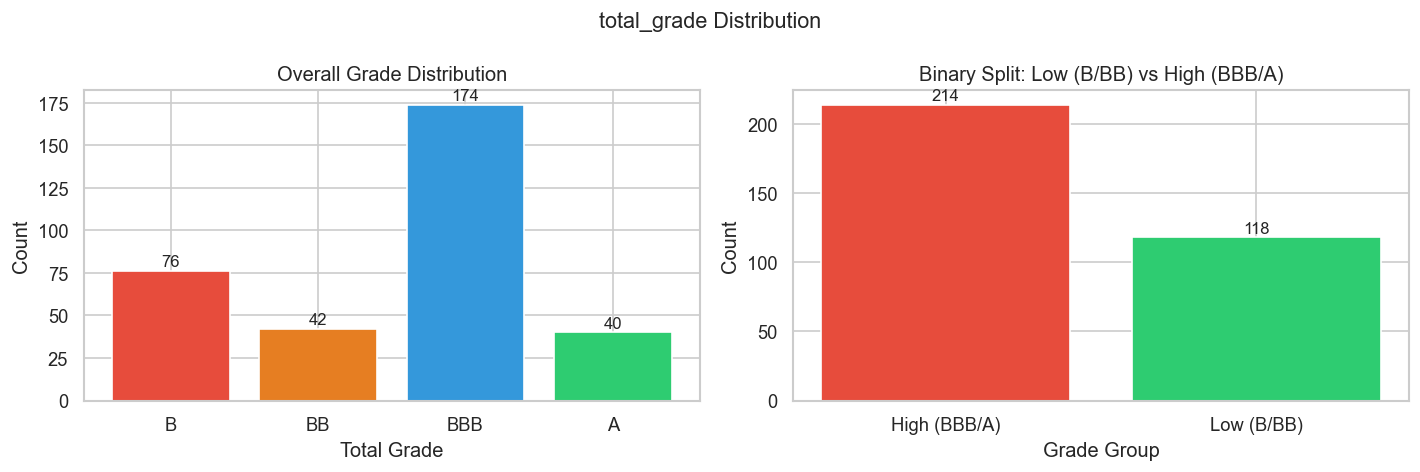

Grade proportions:
     B: 22.9%
    BB: 12.7%
   BBB: 52.4%
     A: 12.0%


In [27]:
# Grade ordering and colour palette
GRADE_ORDER  = ['B', 'BB', 'BBB', 'A']
GRADE_COLORS = {'B': '#e74c3c', 'BB': '#e67e22', 'BBB': '#3498db', 'A': '#2ecc71'}

df['total_grade'] = pd.Categorical(df['total_grade'], categories=GRADE_ORDER, ordered=True)

# ── 1. Overall grade distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['total_grade'].value_counts().reindex(GRADE_ORDER)
bars = axes[0].bar(counts.index, counts.values,
                   color=[GRADE_COLORS[g] for g in counts.index], edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(val), ha='center', va='bottom', fontsize=10)
axes[0].set_xlabel('Total Grade')
axes[0].set_ylabel('Count')
axes[0].set_title('Overall Grade Distribution')

# Collapse to binary: Low (B/BB) vs High (BBB/A)
df['grade_binary'] = df['total_grade'].apply(
    lambda g: 'High (BBB/A)' if g in ('BBB', 'A') else 'Low (B/BB)'
)
bin_counts = df['grade_binary'].value_counts()
axes[1].bar(bin_counts.index, bin_counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white')
for i, (label, val) in enumerate(bin_counts.items()):
    axes[1].text(i, val + 1, str(val), ha='center', va='bottom', fontsize=10)
axes[1].set_xlabel('Grade Group')
axes[1].set_ylabel('Count')
axes[1].set_title('Binary Split: Low (B/BB) vs High (BBB/A)')

plt.suptitle('total_grade Distribution', fontsize=13)
plt.tight_layout()
plt.show()

pct = df['total_grade'].value_counts(normalize=True).reindex(GRADE_ORDER) * 100
print("Grade proportions:")
for g, p in pct.items():
    print(f"  {g:>4s}: {p:.1f}%")

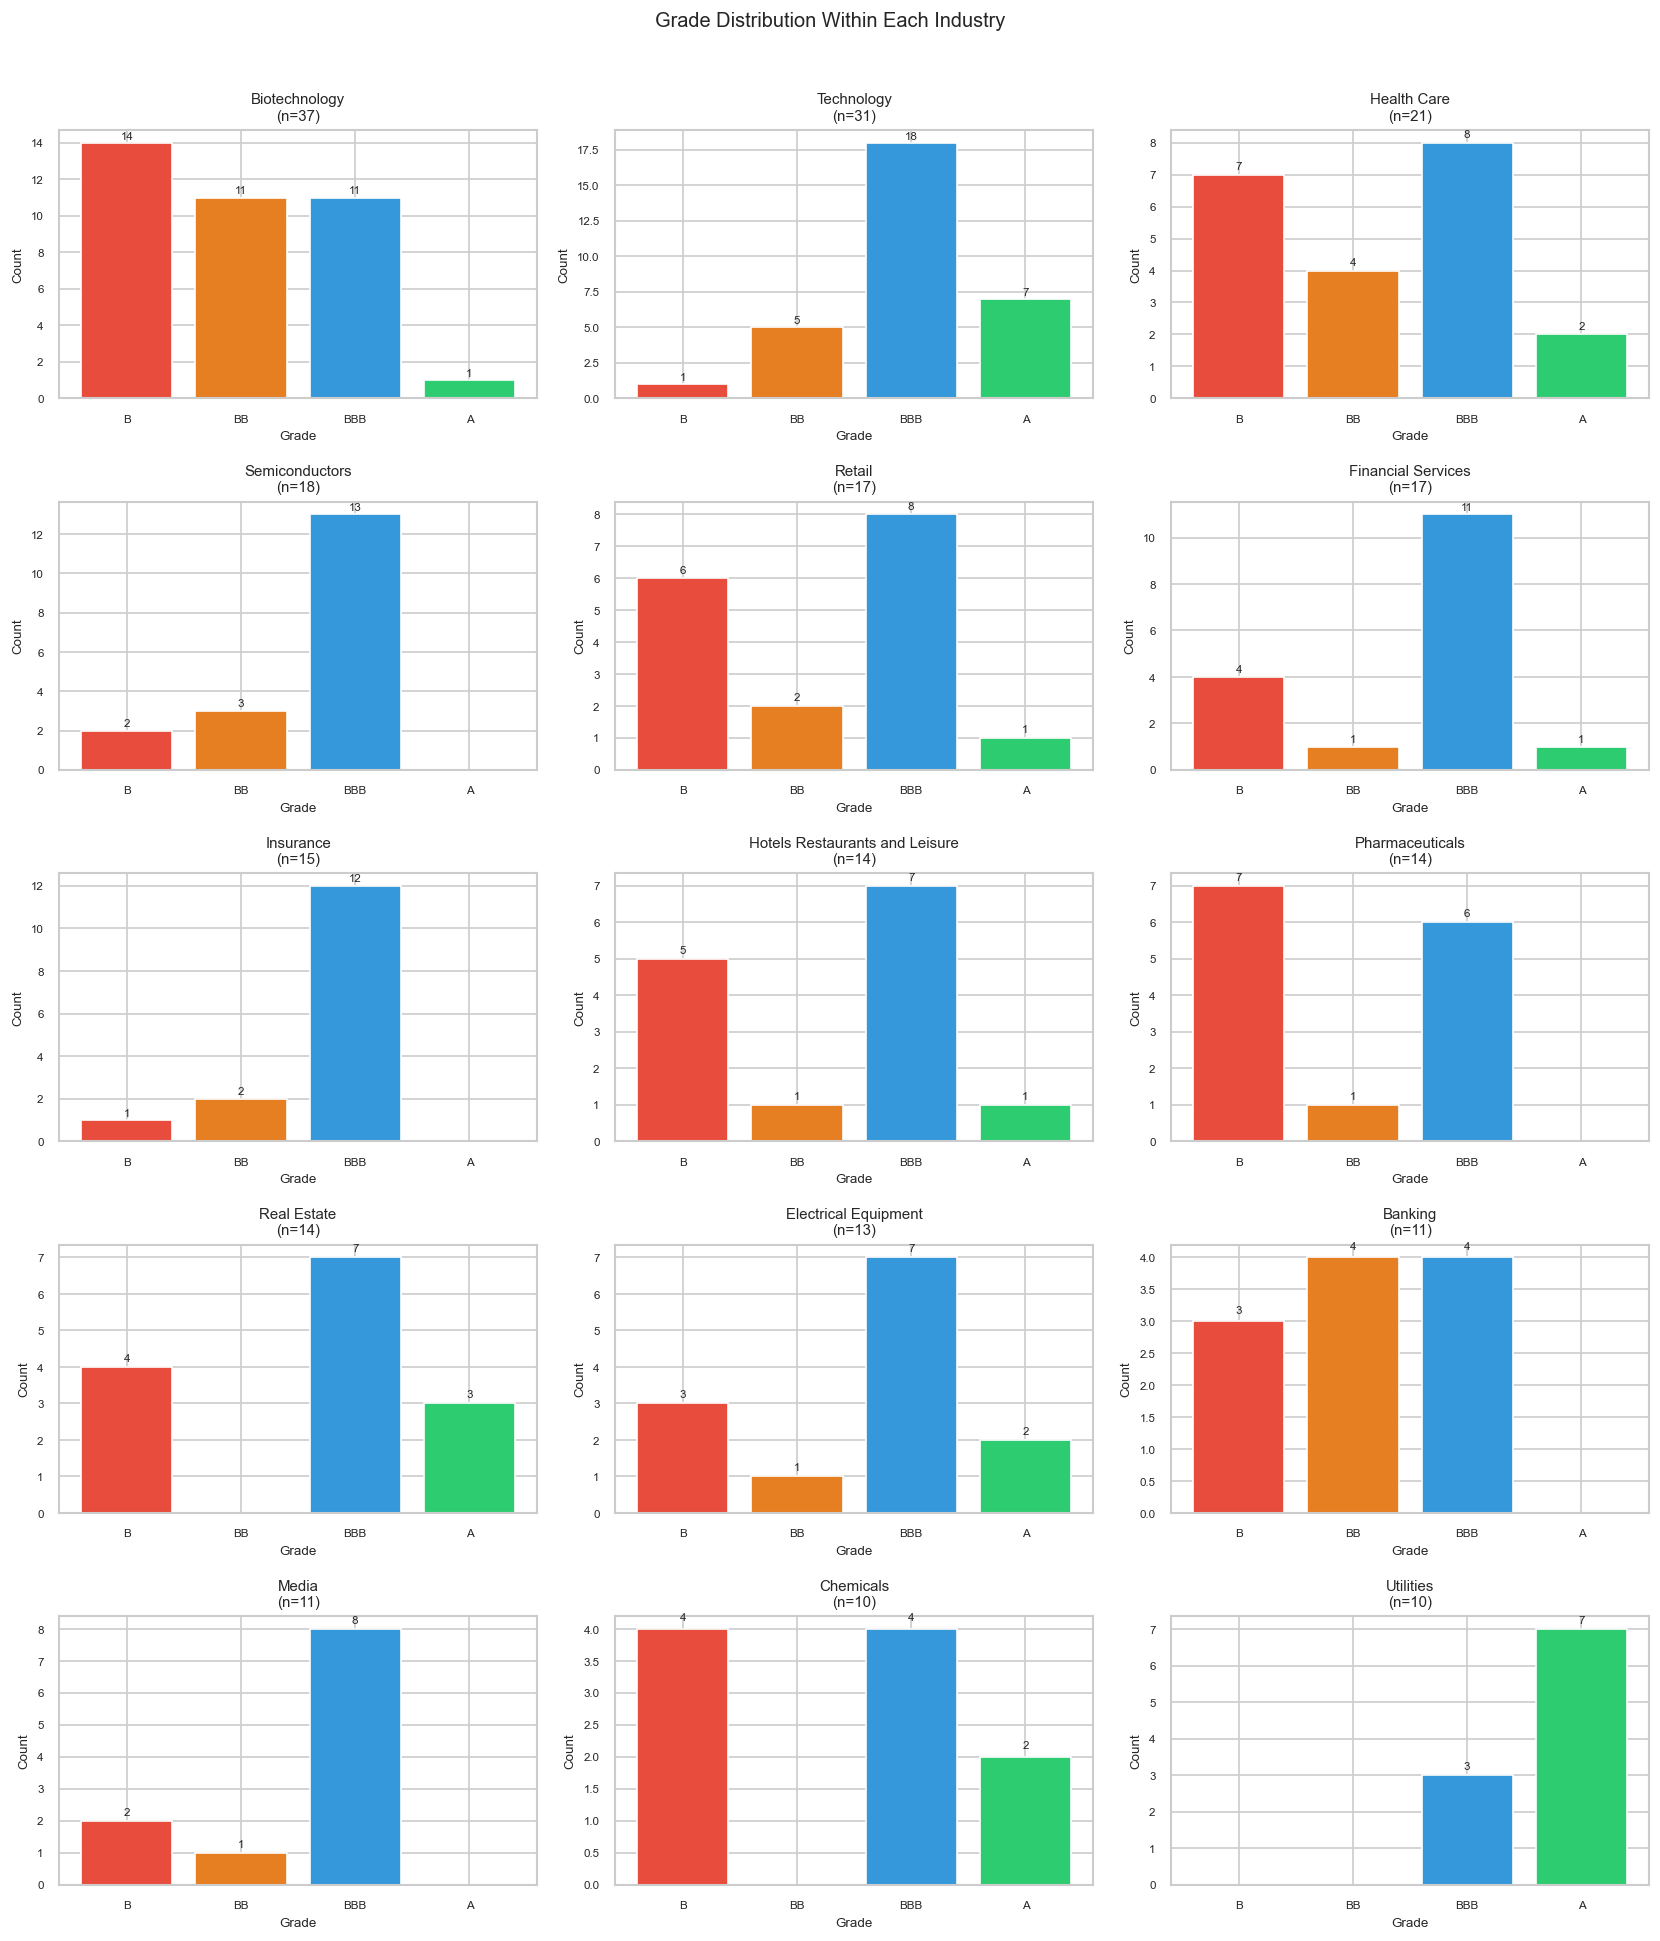

In [28]:
# ── 2. Grade distribution within each industry ────────────────────────────────
top_industries_grade = (df['industry'].value_counts()
                          .loc[lambda s: s >= MIN_COMPANIES]
                          .index.tolist())

n = len(top_industries_grade)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.2))
axes = axes.flatten()

for i, ind in enumerate(top_industries_grade):
    ax = axes[i]
    subset = df[df['industry'] == ind]
    ind_counts = subset['total_grade'].value_counts().reindex(GRADE_ORDER, fill_value=0)
    bars = ax.bar(ind_counts.index, ind_counts.values,
                  color=[GRADE_COLORS[g] for g in ind_counts.index], edgecolor='white')
    for bar, val in zip(bars, ind_counts.values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                    str(val), ha='center', va='bottom', fontsize=7)
    ax.set_title(f'{ind}\n(n={len(subset)})', fontsize=9)
    ax.set_xlabel('Grade', fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Grade Distribution Within Each Industry', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

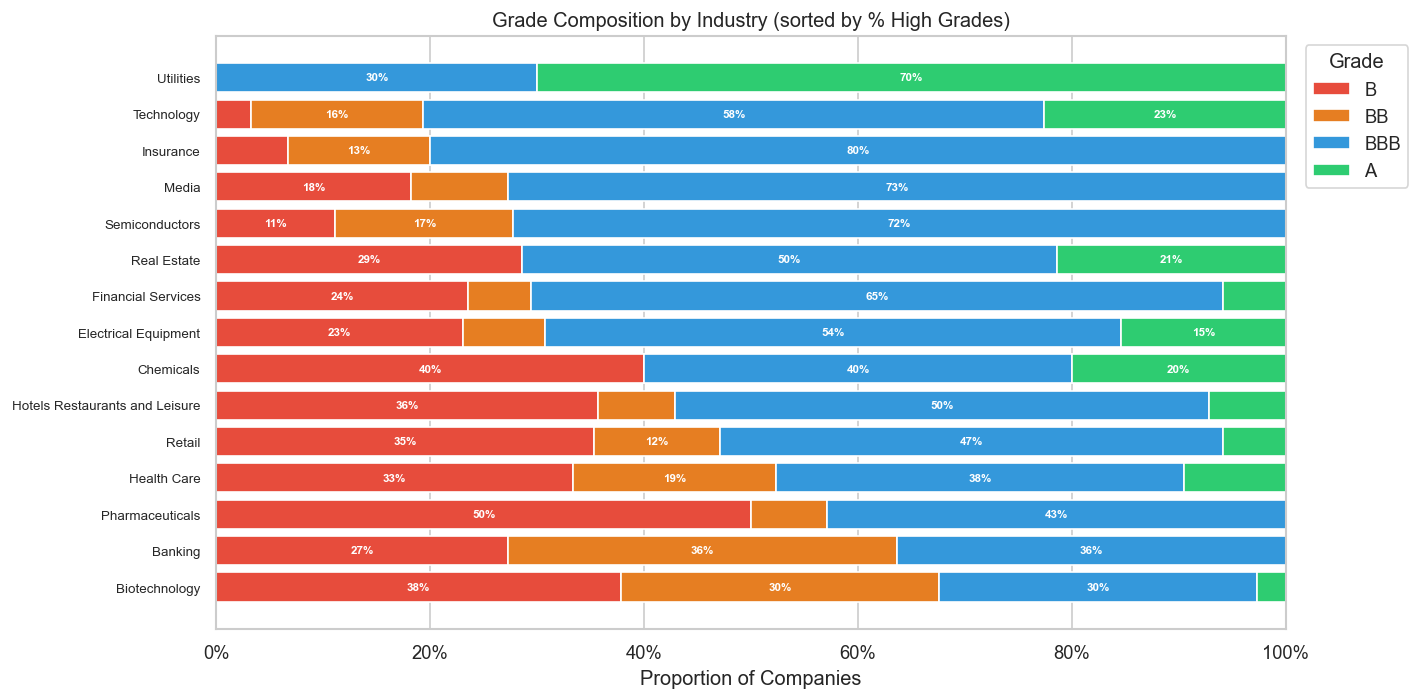

In [29]:
# ── 3. Industry stacked-bar — proportion of each grade per industry ───────────
grade_by_ind = (df[df['industry'].isin(top_industries_grade)]
                  .groupby('industry')['total_grade']
                  .value_counts(normalize=True)
                  .unstack(fill_value=0)
                  .reindex(columns=GRADE_ORDER, fill_value=0))

# Sort industries by proportion of high grades (BBB + A)
grade_by_ind['_high'] = grade_by_ind['BBB'] + grade_by_ind['A']
grade_by_ind = grade_by_ind.sort_values('_high').drop(columns='_high')

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(grade_by_ind))
for grade in GRADE_ORDER:
    vals = grade_by_ind[grade].values
    ax.barh(grade_by_ind.index, vals, left=bottom,
            color=GRADE_COLORS[grade], edgecolor='white', label=grade)
    # Label segments > 10%
    for j, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.10:
            ax.text(b + v / 2, j, f'{v:.0%}', ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')
    bottom += vals

ax.set_xlabel('Proportion of Companies')
ax.set_title('Grade Composition by Industry (sorted by % High Grades)')
ax.legend(title='Grade', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='y', labelsize=8)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

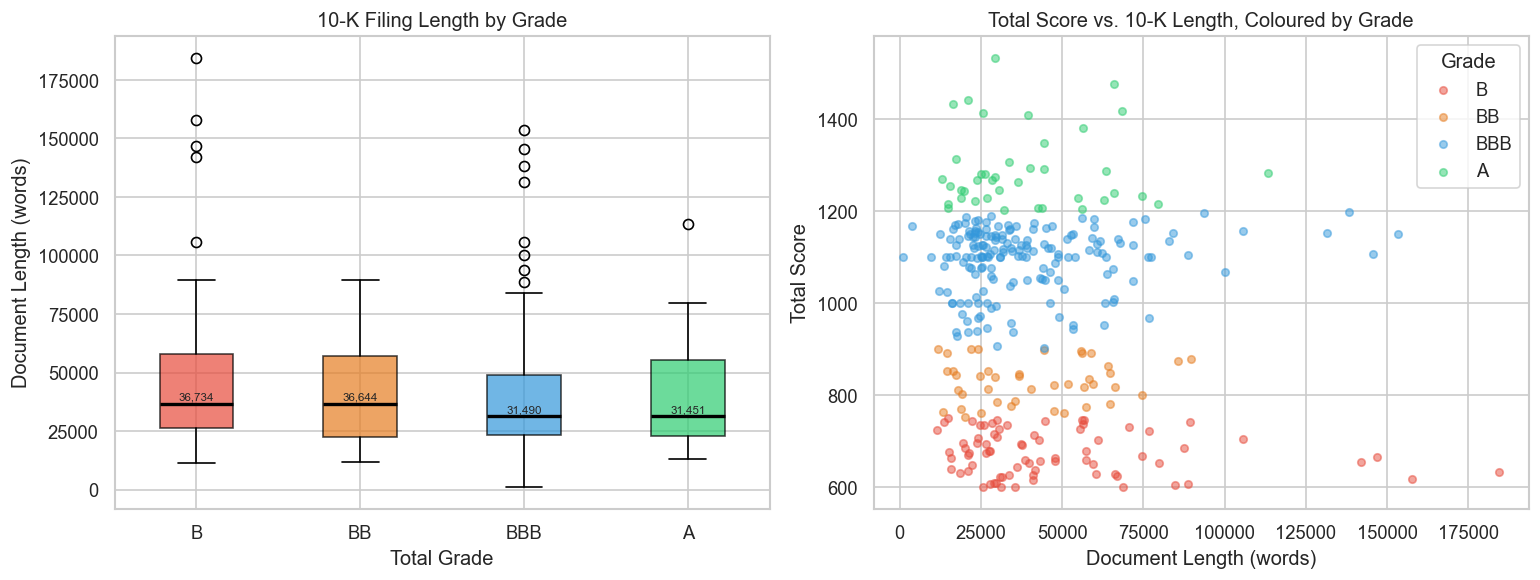

Kruskal-Wallis test (doc_length across grades): H=3.00, p=0.3920

Median doc_length by grade:
     B:     36,734 words  (n=76)
    BB:     36,644 words  (n=42)
   BBB:     31,490 words  (n=174)
     A:     31,451 words  (n=40)


In [30]:
# ── 4. Company size (doc_length) by grade ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot of doc_length per grade
grade_groups = [df.loc[df['total_grade'] == g, 'doc_length'].dropna() for g in GRADE_ORDER]
bp = axes[0].boxplot(grade_groups, labels=GRADE_ORDER, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, grade in zip(bp['boxes'], GRADE_ORDER):
    patch.set_facecolor(GRADE_COLORS[grade])
    patch.set_alpha(0.7)
for i, (grade, grp) in enumerate(zip(GRADE_ORDER, grade_groups), start=1):
    axes[0].text(i, grp.median() * 1.02, f'{grp.median():,.0f}',
                 ha='center', va='bottom', fontsize=7)
axes[0].set_ylabel('Document Length (words)')
axes[0].set_xlabel('Total Grade')
axes[0].set_title('10-K Filing Length by Grade')

# Scatter: doc_length vs total_score, coloured by grade
for grade in GRADE_ORDER:
    sub = df[df['total_grade'] == grade]
    axes[1].scatter(sub['doc_length'], sub['total_score'],
                    alpha=0.5, s=20, color=GRADE_COLORS[grade], label=grade)
axes[1].set_xlabel('Document Length (words)')
axes[1].set_ylabel('Total Score')
axes[1].set_title('Total Score vs. 10-K Length, Coloured by Grade')
axes[1].legend(title='Grade')

plt.tight_layout()
plt.show()

# Kruskal-Wallis test across all four grade groups
from scipy.stats import kruskal
stat, p = kruskal(*grade_groups)
print(f"Kruskal-Wallis test (doc_length across grades): H={stat:.2f}, p={p:.4f}")
print("\nMedian doc_length by grade:")
for grade, grp in zip(GRADE_ORDER, grade_groups):
    print(f"  {grade:>4s}: {grp.median():>10,.0f} words  (n={len(grp)})")

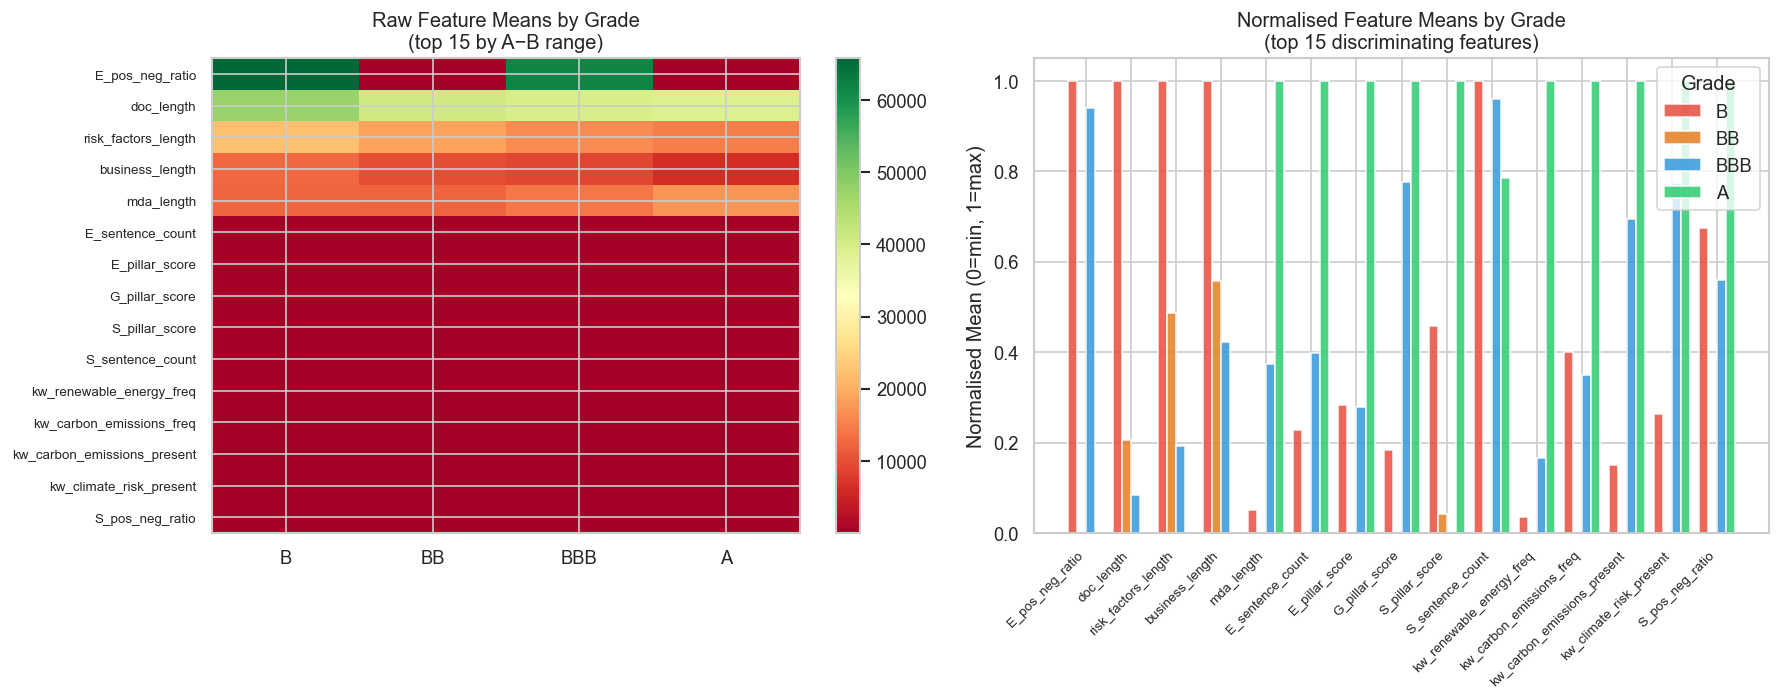


Top 15 features by A−B mean difference:

                                     B         BB        BBB          A      range
E_pos_neg_ratio              65790.068      0.227  61840.108      2.075 -65787.993
doc_length                   47421.763  40676.048  39655.466  38933.700  -8488.063
risk_factors_length          22293.737  18579.619  16443.943  15058.050  -7235.687
business_length              12640.184   9881.143   9039.833   6411.875  -6228.309
mda_length                   12487.842  12215.286  14171.690  17463.775   4975.933
E_sentence_count                25.224     15.881     32.276     56.950     31.726
E_pillar_score                  52.779     50.247     52.746     59.185      6.406
G_pillar_score                  54.238     53.672     56.051     56.741      2.503
S_pillar_score                  58.115     57.124     57.024     59.406      1.291
S_sentence_count                89.211     85.214     89.046     88.350     -0.861
kw_renewable_energy_freq         0.093      0

In [31]:
# ── 5. Feature means by grade — top discriminating features ──────────────────
exclude_grade = ESG_SCORES + ['total_score', 'ticker', 'company', 'cik', 'year',
                               'total_grade', 'grade_binary',
                               'environment_level', 'social_level', 'governance_level']
numeric_cols_g = [c for c in df.select_dtypes(include='number').columns
                  if c not in exclude_grade]

grade_means = df.groupby('total_grade')[numeric_cols_g].mean().T
grade_means.columns = GRADE_ORDER  # ensure correct order

# Rank by range (A mean − B mean) as a measure of how well each feature separates grades
grade_means['range'] = grade_means['A'] - grade_means['B']
top_feats = grade_means['range'].abs().sort_values(ascending=False).head(15).index
top_means = grade_means.loc[top_feats, GRADE_ORDER]

# Normalise each feature to [0,1] for visual comparison
top_norm = top_means.sub(top_means.min(axis=1), axis=0)
top_norm = top_norm.div(top_norm.max(axis=1).replace(0, np.nan), axis=0).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: raw means heatmap
import matplotlib.colors as mcolors
im = axes[0].imshow(top_means.values, aspect='auto', cmap='RdYlGn')
axes[0].set_xticks(range(len(GRADE_ORDER)))
axes[0].set_xticklabels(GRADE_ORDER)
axes[0].set_yticks(range(len(top_feats)))
axes[0].set_yticklabels(top_feats, fontsize=8)
axes[0].set_title('Raw Feature Means by Grade\n(top 15 by A−B range)')
plt.colorbar(im, ax=axes[0])

# Right: grouped bar — normalised means
x = np.arange(len(top_feats))
width = 0.2
for j, grade in enumerate(GRADE_ORDER):
    axes[1].bar(x + j * width, top_norm[grade], width,
                label=grade, color=GRADE_COLORS[grade], edgecolor='white', alpha=0.85)
axes[1].set_xticks(x + 1.5 * width)
axes[1].set_xticklabels(top_feats, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Normalised Mean (0=min, 1=max)')
axes[1].set_title('Normalised Feature Means by Grade\n(top 15 discriminating features)')
axes[1].legend(title='Grade')

plt.tight_layout()
plt.show()

print("\nTop 15 features by A−B mean difference:\n")
print(grade_means.loc[top_feats, GRADE_ORDER + ['range']].round(3).to_string())

---

## UMAP of FinBERT Features

PCA finds the directions of maximum *linear* variance, but the structure in high-dimensional FinBERT features may be curved or clustered non-linearly. UMAP (Uniform Manifold Approximation and Projection) preserves both local neighbourhood structure and global layout, often revealing clusters that PCA flattens out.

We run UMAP on the FinBERT-derived features (sentiment means/stds, pillar scores, coverage percentages) and compare the layout to PCA on the same features, colouring points by `total_grade` and `industry`.

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("umap-learn not installed. Run:  pip install umap-learn")

# ── Feature set: FinBERT sentiment + pillar scores + coverage ─────────────────
FINBERT_COLS = (
    SENTIMENT_COLS          # E/S/G pos_mean, neg_mean, neu_mean, pos_std, neg_std
    + PILLAR_SCORES         # E_pillar_score, S_pillar_score, G_pillar_score
    + COVERAGE_COLS         # E_coverage_pct, S_coverage_pct, G_coverage_pct
    + ['E_sentence_count', 'S_sentence_count', 'G_sentence_count']
)

# Drop any columns not actually present (safety check)
FINBERT_COLS = [c for c in FINBERT_COLS if c in df.columns]

X_fin = df[FINBERT_COLS].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_fin)

# Grade colour map — reuse GRADE_COLORS if defined, else define here
if 'GRADE_COLORS' not in dir():
    GRADE_ORDER  = ['B', 'BB', 'BBB', 'A']
    GRADE_COLORS = {'B': '#e74c3c', 'BB': '#e67e22', 'BBB': '#3498db', 'A': '#2ecc71'}

if 'total_grade' not in df.columns:
    df['total_grade'] = pd.Categorical(df['total_grade'], categories=GRADE_ORDER, ordered=True)

grade_colors_mapped = df['total_grade'].map(GRADE_COLORS).fillna('grey')

print(f"Feature matrix: {X_scaled.shape[0]} companies × {X_scaled.shape[1]} FinBERT features")
print(f"Features used: {FINBERT_COLS}")

Feature matrix: 332 companies × 18 FinBERT features
Features used: ['E_pos_mean', 'E_neg_mean', 'E_neu_mean', 'S_pos_mean', 'S_neg_mean', 'S_neu_mean', 'G_pos_mean', 'G_neg_mean', 'G_neu_mean', 'E_pillar_score', 'S_pillar_score', 'G_pillar_score', 'E_coverage_pct', 'S_coverage_pct', 'G_coverage_pct', 'E_sentence_count', 'S_sentence_count', 'G_sentence_count']


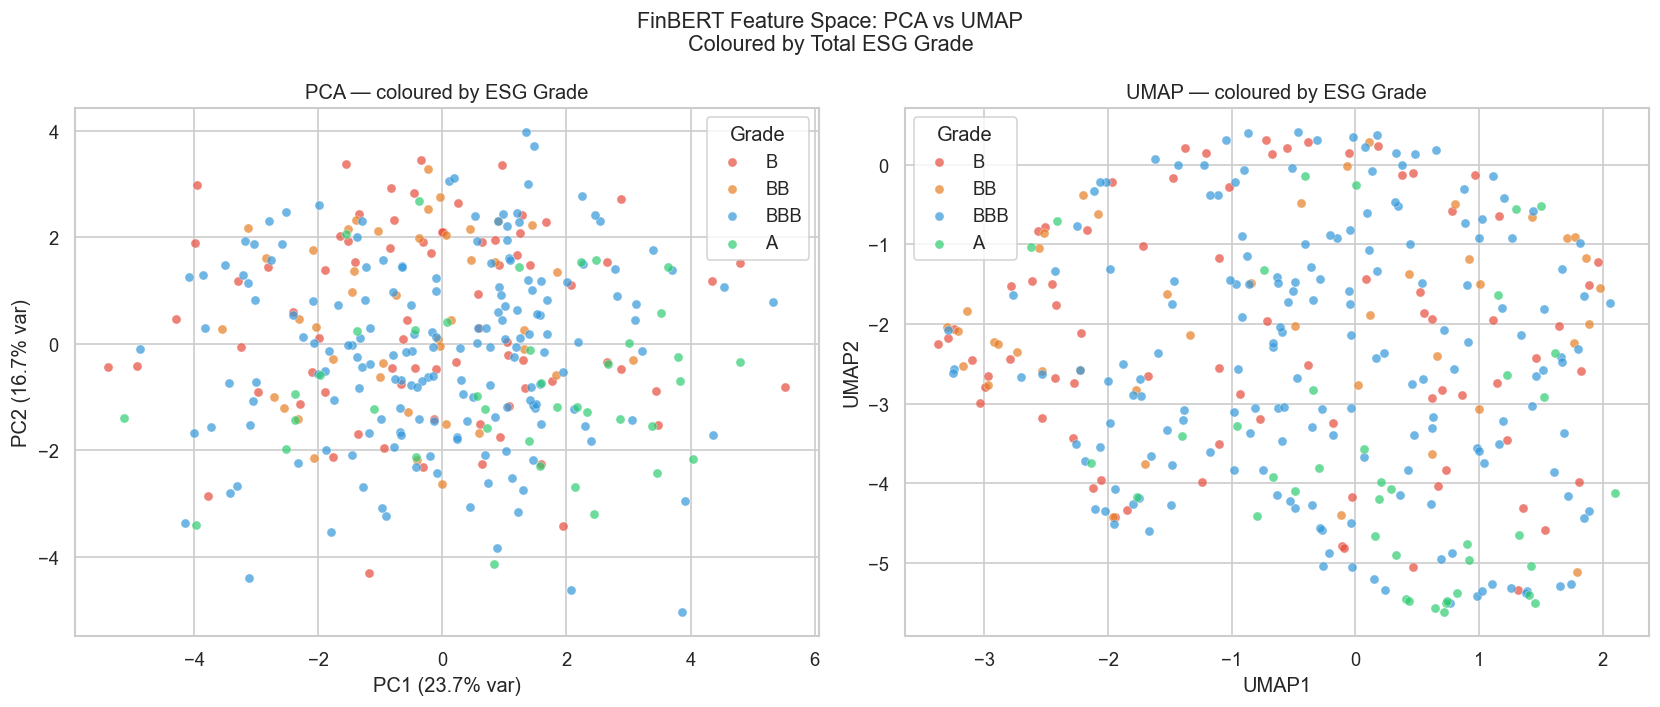

PCA variance explained — PC1: 23.7%, PC2: 16.7%, total: 40.4%


In [38]:
# ── PCA (2D) for baseline comparison ─────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# ── UMAP (2D) ─────────────────────────────────────────────────────────────────
if HAS_UMAP:
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        metric='euclidean', random_state=42)
    X_umap = reducer.fit_transform(X_scaled)

# ── Side-by-side: PCA vs UMAP, coloured by grade ─────────────────────────────
ncols = 2 if HAS_UMAP else 1
fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6))
if ncols == 1:
    axes = [axes]

for ax, coords, title in zip(
    axes,
    [X_pca] + ([X_umap] if HAS_UMAP else []),
    ['PCA', 'UMAP'] if HAS_UMAP else ['PCA'],
):
    for grade in GRADE_ORDER:
        mask = df['total_grade'] == grade
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=GRADE_COLORS[grade], label=grade,
                   s=30, alpha=0.7, edgecolors='white', linewidths=0.3)
    ax.set_title(f'{title} — coloured by ESG Grade', fontsize=12)
    ax.set_xlabel(f'{title}1')
    ax.set_ylabel(f'{title}2')
    ax.legend(title='Grade', loc='best')

var_exp = pca.explained_variance_ratio_
axes[0].set_xlabel(f'PC1 ({var_exp[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({var_exp[1]:.1%} var)')

plt.suptitle('FinBERT Feature Space: PCA vs UMAP\nColoured by Total ESG Grade', fontsize=13)
plt.tight_layout()
plt.show()

print(f"PCA variance explained — PC1: {var_exp[0]:.1%}, PC2: {var_exp[1]:.1%}, "
      f"total: {sum(var_exp):.1%}")

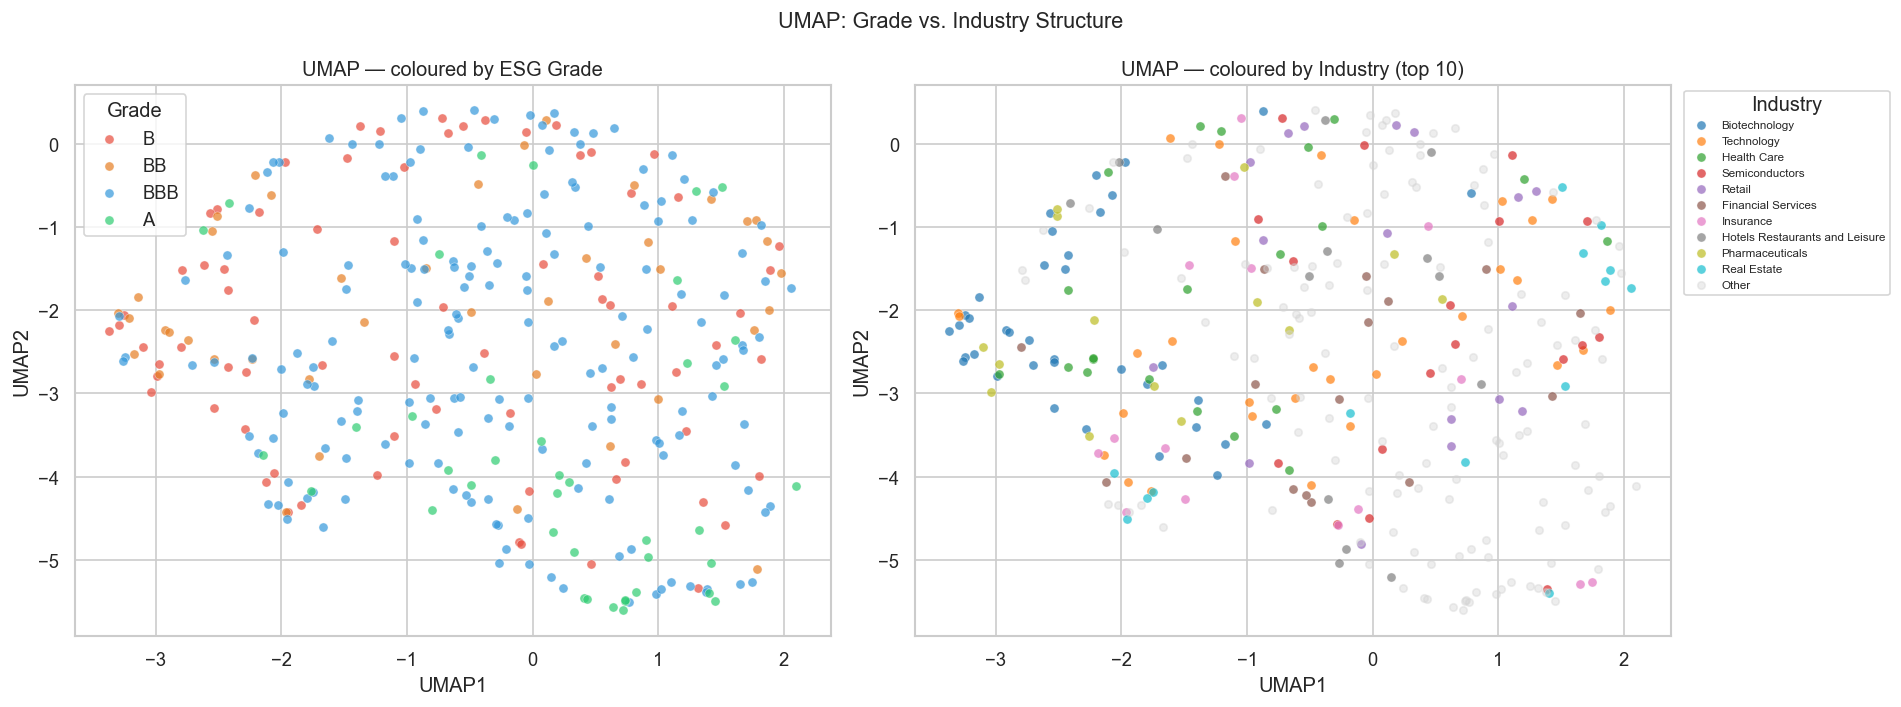

In [39]:
# ── Colour by industry to separate industry effect from grade signal ──────────
if HAS_UMAP:
    industries = df['industry'].fillna('Unknown')
    unique_inds = industries.value_counts().head(10).index.tolist()  # top 10 for legibility
    ind_palette = plt.cm.tab10.colors

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left: UMAP coloured by grade
    for grade in GRADE_ORDER:
        mask = df['total_grade'] == grade
        axes[0].scatter(X_umap[mask, 0], X_umap[mask, 1],
                        c=GRADE_COLORS[grade], label=grade,
                        s=30, alpha=0.7, edgecolors='white', linewidths=0.3)
    axes[0].set_title('UMAP — coloured by ESG Grade')
    axes[0].legend(title='Grade')

    # Right: UMAP coloured by industry
    for i, ind in enumerate(unique_inds):
        mask = industries == ind
        axes[1].scatter(X_umap[mask, 0], X_umap[mask, 1],
                        color=ind_palette[i % 10], label=ind,
                        s=30, alpha=0.7, edgecolors='white', linewidths=0.3)
    # plot remaining industries as grey
    other_mask = ~industries.isin(unique_inds)
    if other_mask.any():
        axes[1].scatter(X_umap[other_mask, 0], X_umap[other_mask, 1],
                        color='lightgrey', s=20, alpha=0.4, label='Other')
    axes[1].set_title('UMAP — coloured by Industry (top 10)')
    axes[1].legend(title='Industry', fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')

    for ax in axes:
        ax.set_xlabel('UMAP1')
        ax.set_ylabel('UMAP2')

    plt.suptitle('UMAP: Grade vs. Industry Structure', fontsize=13)
    plt.tight_layout()
    plt.show()

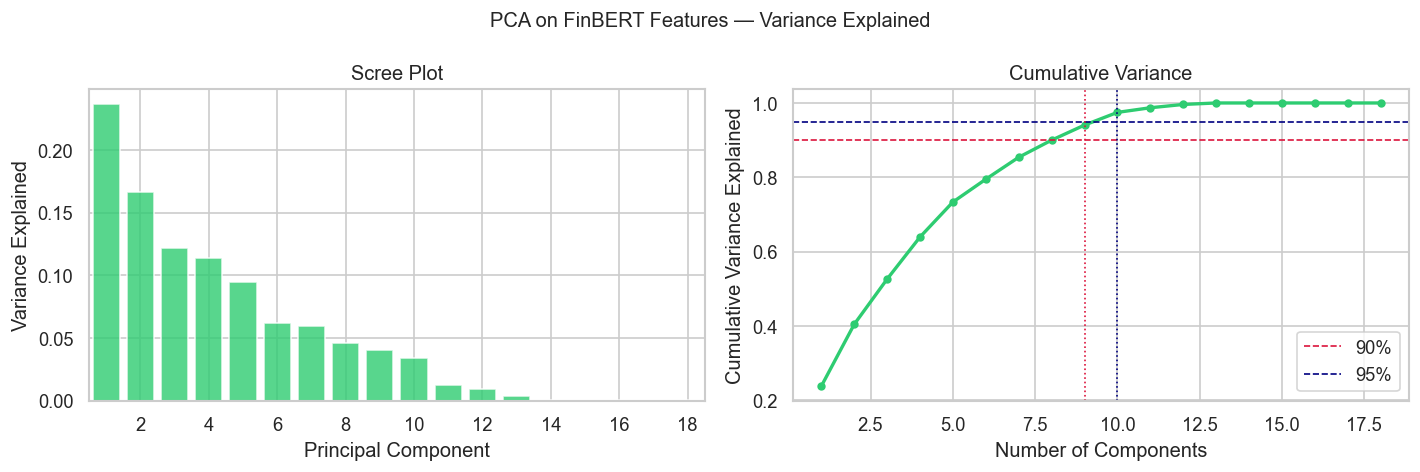

Components needed for 90% variance: 9
Components needed for 95% variance: 10
Total features: 18


In [40]:
# ── PCA scree plot: how many components are needed to explain the variance? ───
pca_full = PCA(random_state=42).fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n90 = int(np.searchsorted(cumvar, 0.90)) + 1
n95 = int(np.searchsorted(cumvar, 0.95)) + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_,
            color=PILLAR_COLORS['E'], edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('Scree Plot')
axes[0].set_xlim(0.5, min(20, len(pca_full.explained_variance_ratio_)) + 0.5)

axes[1].plot(range(1, len(cumvar) + 1), cumvar,
             color=PILLAR_COLORS['E'], linewidth=2, marker='o', markersize=4)
axes[1].axhline(0.90, color='crimson', linestyle='--', linewidth=1, label='90%')
axes[1].axhline(0.95, color='navy',    linestyle='--', linewidth=1, label='95%')
axes[1].axvline(n90, color='crimson', linestyle=':', linewidth=1)
axes[1].axvline(n95, color='navy',    linestyle=':', linewidth=1)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Variance')
axes[1].legend()

plt.suptitle('PCA on FinBERT Features — Variance Explained', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Components needed for 90% variance: {n90}")
print(f"Components needed for 95% variance: {n95}")
print(f"Total features: {X_scaled.shape[1]}")

---

## 10-K Extraction Quality Audit: Truncation, Duplicates, and XBRL Contamination

Investigates three data quality concerns in the extracted sections:

1. **500k character cap** — the extraction pipeline hard-caps each section at 500,000 chars. Sections that hit this limit are truncated, and for some filings the cap causes the extractor to pull structured financial XBRL tables instead of narrative text.
2. **Duplicate sentences** — repeated boilerplate, cross-references, or overlapping section boundaries cause the same sentences to appear multiple times. FinBERT features computed over these sentences will have inflated sentiment signals for affected companies.
3. **XBRL/HTML contamination** — some filings are stored in iXBRL format where financial data tags are interleaved with narrative text. If the extractor picks up the structured-data block, it produces base64/XML content that FinBERT cannot interpret meaningfully.


=== Extraction Audit Summary ===
Total section records:          1032
Sections hitting 500k cap:      30 (2.9%)
Sections with XBRL markup:      2
Mean duplicate sentence rate:   1.20%

--- Modeling set (332 companies) ---
Cap-hit sections in model:      28
Companies with any cap hit:     21
Mean dupe rate (model set):     1.19%


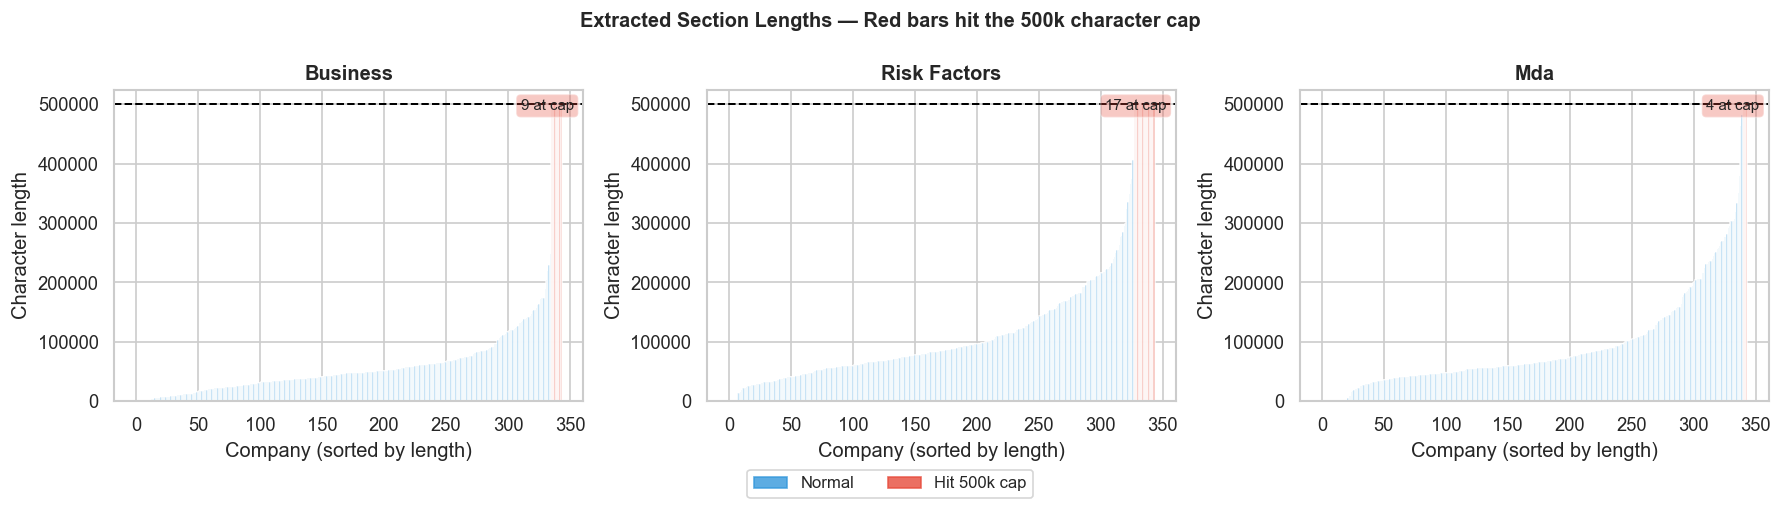

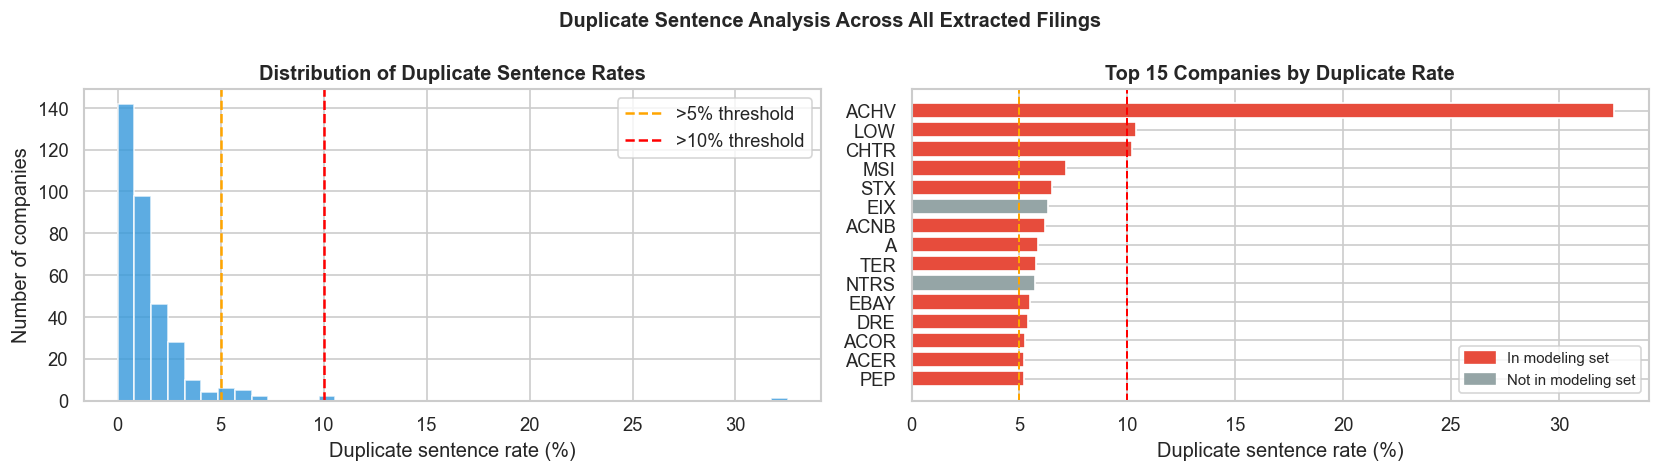


Modeling companies with >5% duplicate sentence rate:
        total_sentences  total_dupes  dupe_pct  cap_hits   xbrl
ticker                                                         
ACHV               3783         1231      32.5         1  False
LOW                5532          575      10.4         2  False
CHTR               3267          334      10.2         1  False
MSI                3753          269       7.2         1  False
STX                2652          173       6.5         1  False
ACNB               4978          308       6.2         2  False
A                  1382           81       5.9         0  False
TER                5208          300       5.8         2  False
EBAY               4900          268       5.5         2  False
DRE                2435          131       5.4         1  False
ACOR               2282          120       5.3         0  False
ACER               1970          103       5.2         0  False
PEP                2296          120       5.2    

In [8]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

SECTIONS_DIR = '../data/extracted_sections'
CAP = 500_000

merged_audit = pd.read_csv('../data/finbert_features/merged_features_labels.csv')
modeling_tickers = set(merged_audit['ticker'].str.upper())

# ── Audit all extracted section files ────────────────────────────────────────
records = []
for fname in sorted(os.listdir(SECTIONS_DIR)):
    ticker = fname.replace('.json', '').upper()
    with open(os.path.join(SECTIONS_DIR, fname), encoding='utf-8', errors='ignore') as fh:
        data = json.load(fh)
    sections = data.get('sections', {}) or {}
    for sec_name in ['business', 'risk_factors', 'mda']:
        text = sections.get(sec_name, '') or ''
        sentences = [s.strip() for s in text.split('.') if len(s.strip()) > 30]
        total = len(sentences)
        dupes = total - len(set(sentences))
        records.append({
            'ticker':      ticker,
            'section':     sec_name,
            'char_len':    len(text),
            'hit_cap':     len(text) == CAP,
            'xbrl':        'contextRef=' in text or 'unitRef=' in text,
            'n_sentences': total,
            'n_dupes':     dupes,
            'dupe_pct':    100 * dupes / max(total, 1),
            'in_model':    ticker in modeling_tickers,
        })

audit = pd.DataFrame(records)
model_audit = audit[audit['in_model']]

print('=== Extraction Audit Summary ===')
print(f'Total section records:          {len(audit)}')
print(f'Sections hitting 500k cap:      {audit["hit_cap"].sum()} ({audit["hit_cap"].sum()/len(audit)*100:.1f}%)')
print(f'Sections with XBRL markup:      {audit["xbrl"].sum()}')
print(f'Mean duplicate sentence rate:   {audit["dupe_pct"].mean():.2f}%')
print()
print('--- Modeling set (332 companies) ---')
print(f'Cap-hit sections in model:      {model_audit["hit_cap"].sum()}')
print(f'Companies with any cap hit:     {model_audit[model_audit["hit_cap"]]["ticker"].nunique()}')
print(f'Mean dupe rate (model set):     {model_audit["dupe_pct"].mean():.2f}%')

# ── Plot 1: Section char lengths with cap line ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, sec in zip(axes, ['business', 'risk_factors', 'mda']):
    sub = audit[audit['section'] == sec].sort_values('char_len')
    colors = ['#e74c3c' if h else '#3498db' for h in sub['hit_cap']]
    ax.bar(range(len(sub)), sub['char_len'], color=colors, width=1.0, alpha=0.8)
    ax.axhline(CAP, color='black', linestyle='--', linewidth=1.2, label='500k cap')
    ax.set_title(sec.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('Company (sorted by length)')
    ax.set_ylabel('Character length')
    cap_n = sub['hit_cap'].sum()
    ax.text(0.98, 0.97, f'{cap_n} at cap', transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#e74c3c', alpha=0.3))
blue_patch = mpatches.Patch(color='#3498db', alpha=0.8, label='Normal')
red_patch  = mpatches.Patch(color='#e74c3c', alpha=0.8, label='Hit 500k cap')
fig.legend(handles=[blue_patch, red_patch], loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.05), fontsize=10)
plt.suptitle('Extracted Section Lengths — Red bars hit the 500k character cap',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Plot 2: Duplicate sentence rate distribution ──────────────────────────────
company_dupes = (
    audit.groupby('ticker')
    .apply(lambda g: 100 * g['n_dupes'].sum() / max(g['n_sentences'].sum(), 1))
    .reset_index(name='dupe_pct')
)
company_dupes['in_model'] = company_dupes['ticker'].isin(modeling_tickers)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(company_dupes['dupe_pct'], bins=40, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(5,  color='orange', linestyle='--', linewidth=1.5, label='>5% threshold')
axes[0].axvline(10, color='red',    linestyle='--', linewidth=1.5, label='>10% threshold')
axes[0].set_xlabel('Duplicate sentence rate (%)')
axes[0].set_ylabel('Number of companies')
axes[0].set_title('Distribution of Duplicate Sentence Rates', fontweight='bold')
axes[0].legend()

worst = company_dupes.nlargest(15, 'dupe_pct').copy()
colors_w = ['#e74c3c' if m else '#95a5a6' for m in worst['in_model']]
axes[1].barh(worst['ticker'], worst['dupe_pct'], color=colors_w, edgecolor='white')
axes[1].axvline(5,  color='orange', linestyle='--', linewidth=1.2)
axes[1].axvline(10, color='red',    linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Duplicate sentence rate (%)')
axes[1].set_title('Top 15 Companies by Duplicate Rate', fontweight='bold')
red_p  = mpatches.Patch(color='#e74c3c', label='In modeling set')
grey_p = mpatches.Patch(color='#95a5a6', label='Not in modeling set')
axes[1].legend(handles=[red_p, grey_p], fontsize=9)
axes[1].invert_yaxis()
plt.suptitle('Duplicate Sentence Analysis Across All Extracted Filings',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Worst offenders table ─────────────────────────────────────────────────────
print('\nModeling companies with >5% duplicate sentence rate:')
bad = model_audit.groupby('ticker').apply(
    lambda g: pd.Series({
        'total_sentences': int(g['n_sentences'].sum()),
        'total_dupes':     int(g['n_dupes'].sum()),
        'dupe_pct':        round(100 * g['n_dupes'].sum() / max(g['n_sentences'].sum(), 1), 1),
        'cap_hits':        int(g['hit_cap'].sum()),
        'xbrl':            bool(g['xbrl'].any()),
    })
).query('dupe_pct > 5').sort_values('dupe_pct', ascending=False)
print(bad.to_string())

# ── Spot-check duplicate sentences for worst offender ────────────────────────
worst_ticker = bad.index[0]
print(f'\nSample repeated sentences from {worst_ticker}:')
with open(os.path.join(SECTIONS_DIR, f'{worst_ticker}.json'), encoding='utf-8', errors='ignore') as fh:
    sample_data = json.load(fh)
sample_sections = sample_data.get('sections', {}) or {}
all_sents = []
for text in sample_sections.values():
    all_sents += [s.strip() for s in (text or '').split('.') if len(s.strip()) > 30]
seen, shown = set(), 0
for s in all_sents:
    if s in seen and shown < 5:
        print(f'  {s[:120]}')
        shown += 1
    seen.add(s)

# ── XBRL contamination ────────────────────────────────────────────────────────
xbrl_cases = audit[audit['xbrl']]
if len(xbrl_cases) > 0:
    print(f'\nXBRL-contaminated sections ({len(xbrl_cases)} total):')
    print(xbrl_cases[['ticker', 'section', 'char_len']].to_string(index=False))
    ex_ticker  = xbrl_cases.iloc[0]['ticker']
    ex_section = xbrl_cases.iloc[0]['section']
    with open(os.path.join(SECTIONS_DIR, f'{ex_ticker}.json'), encoding='utf-8', errors='ignore') as fh:
        ex_data = json.load(fh)
    ex_text = (ex_data.get('sections', {}) or {}).get(ex_section, '')
    print(f'\nXBRL example ({ex_ticker} {ex_section}) — first 300 chars:')
    print(repr(ex_text[:300]))


---

## Cap-Hit Filing Spot-Check

For each modeling company that hit the 500k cap on at least one section, prints
the first 400 characters of each section. This lets you visually distinguish:
- **Real text** — readable English prose starting with the section heading or first sentence
- **Broken extraction** — XBRL tags, base64 strings, or a short TOC stub

The MDA column is the most diagnostic: a ~162-char MDA is always a TOC stub, not real content.


In [9]:
import json, os
import pandas as pd

SECTIONS_DIR = '../data/extracted_sections'
CAP = 500_000
PREVIEW_LEN = 400
XBRL_SIGNALS = ['contextRef=', 'unitRef=', '<ix:', 'xmlns', '<div']

merged_sc = pd.read_csv('../data/finbert_features/merged_features_labels.csv')
modeling_tickers_sc = set(merged_sc['ticker'].str.upper())

# Collect cap-hit companies in the modeling set
cap_companies = []
for fname in sorted(os.listdir(SECTIONS_DIR)):
    ticker = fname.replace('.json', '').upper()
    if ticker not in modeling_tickers_sc:
        continue
    with open(os.path.join(SECTIONS_DIR, fname), encoding='utf-8', errors='ignore') as fh:
        data = json.load(fh)
    sections = data.get('sections', {}) or {}
    lengths = {s: len(sections.get(s, '') or '') for s in ['business', 'risk_factors', 'mda']}
    if any(l == CAP for l in lengths.values()):
        cap_companies.append((ticker, sections, lengths))

# Summary table
print(f'{len(cap_companies)} modeling companies with at least one cap-hit section\n')
print(f"{'Ticker':<8}  {'Business':>10}  {'Risk Factors':>12}  {'MDA':>10}  Notes")
print('-' * 72)
for ticker, sections, lengths in cap_companies:
    text_all = ''.join((sections.get(s, '') or '') for s in ['business', 'risk_factors', 'mda'])
    notes = []
    if any(sig in text_all for sig in XBRL_SIGNALS):
        notes.append('XBRL')
    if lengths['mda'] < 300:
        notes.append('TOC-stub MDA')
    if lengths['business'] == CAP and lengths['risk_factors'] == CAP:
        notes.append('2-section cap')
    print(f"{ticker:<8}  {lengths['business']:>10,}  {lengths['risk_factors']:>12,}  {lengths['mda']:>10,}  {', '.join(notes)}")

# Section previews
SEP = '=' * 80
for ticker, sections, lengths in cap_companies:
    print()
    print(SEP)
    b, r, m = lengths['business'], lengths['risk_factors'], lengths['mda']
    print(f'  {ticker}  |  business={b:,}  risk_factors={r:,}  mda={m:,}')
    print(SEP)
    for sec_name in ['business', 'risk_factors', 'mda']:
        text = sections.get(sec_name, '') or ''
        preview = text[:PREVIEW_LEN].replace('\n', ' ').strip()
        hit_str  = ' [HIT CAP]' if len(text) == CAP else ''
        xbrl_str = ' *** XBRL ***' if any(sig in text for sig in XBRL_SIGNALS) else ''
        label = sec_name.upper() + hit_str + xbrl_str
        print(f'  [{label}]')
        if len(text) == 0:
            print('    (empty)')
        elif len(text) < 300:
            print(f'    *** SHORT ({len(text)} chars — likely TOC stub): {preview!r}')
        else:
            print(f'    {preview!r}')
        print()


21 modeling companies with at least one cap-hit section

Ticker      Business  Risk Factors         MDA  Notes
------------------------------------------------------------------------
ACHV          95,799       500,000      60,030  
ACNB         500,000       500,000         162  TOC-stub MDA, 2-section cap
AIG          133,705       500,000     261,952  
AKBA         229,326       500,000     500,000  
AKRO         174,559       500,000      46,122  
AKTS         500,000       110,283      22,240  XBRL
AOS          500,000        14,993         162  TOC-stub MDA
ARE            3,233       277,593     500,000  
BX            40,807       373,962     500,000  
CHTR          46,655       500,000      57,850  
COST         500,000       500,000         162  XBRL, TOC-stub MDA, 2-section cap
DRE           21,943       500,000      74,460  
DXCM         500,000       500,000         162  TOC-stub MDA, 2-section cap
EBAY         500,000       500,000         162  TOC-stub MDA, 2-section cap


---

## Bad Extraction Flag

Saves a `bad_extraction` indicator to `data/structured_features/extraction_quality.csv`
based on the spot-check findings. Two severity levels:

- **`bad_extraction = 2` (critical)** — XBRL contamination or 2-section cap with TOC-stub MDA.
  FinBERT features for these companies are meaningless. Strong candidates for exclusion.
- **`bad_extraction = 1` (borderline)** — Single anomaly (unusually small business section,
  unexpected section hitting cap). Features may be degraded but not fully corrupted.
- **`bad_extraction = 0`** — No extraction issues detected.

This flag can be used in the modeling pipeline to filter, weight, or analyse the impact
of bad extractions on model performance.


In [10]:
import pandas as pd
from pathlib import Path

# ── Bad extraction classifications from spot-check ────────────────────────────
# Critical (2): XBRL contamination OR 2-section cap + TOC-stub MDA
CRITICAL = {
    'COST':  'XBRL markup in business + risk_factors',
    'AKTS':  'XBRL markup in business section',
    'NTAP':  'XBRL markup detected',
    'ACNB':  '2-section cap + TOC-stub MDA (162 chars)',
    'DXCM':  '2-section cap + TOC-stub MDA (162 chars)',
    'EBAY':  '2-section cap + TOC-stub MDA (162 chars)',
    'TER':   '2-section cap + TOC-stub MDA (167 chars)',
    'AOS':   '2-section cap + TOC-stub MDA + risk only 15k chars',
    'LOW':   '2-section cap + 11.6% duplicate sentence rate',
}

# Borderline (1): single anomaly, features degraded but not fully corrupted
BORDERLINE = {
    'ARE':  'Business section only 3,233 chars (likely extraction missed section start)',
    'STX':  'Business section hit cap (unusual — typically risk section is longest)',
}

# ── Build flag dataframe for the full modeling set ────────────────────────────
merged_flag = pd.read_csv('../data/finbert_features/merged_features_labels.csv')
merged_flag['ticker'] = merged_flag['ticker'].str.upper()

def get_flag(ticker):
    if ticker in CRITICAL:
        return 2
    if ticker in BORDERLINE:
        return 1
    return 0

def get_reason(ticker):
    if ticker in CRITICAL:
        return CRITICAL[ticker]
    if ticker in BORDERLINE:
        return BORDERLINE[ticker]
    return ''

flag_df = merged_flag[['ticker']].copy()
flag_df['bad_extraction'] = flag_df['ticker'].map(get_flag)
flag_df['extraction_note'] = flag_df['ticker'].map(get_reason)

# ── Save ─────────────────────────────────────────────────────────────────────
out_path = Path('../data/structured_features/extraction_quality.csv')
flag_df.to_csv(out_path, index=False)
print(f'Saved to {out_path}')

# ── Summary ──────────────────────────────────────────────────────────────────
counts = flag_df['bad_extraction'].value_counts().sort_index()
print()
print('Extraction quality summary (modeling set):')
print(f'  0 — clean:      {counts.get(0, 0):>4} companies ({counts.get(0, 0)/len(flag_df)*100:.1f}%)')
print(f'  1 — borderline: {counts.get(1, 0):>4} companies ({counts.get(1, 0)/len(flag_df)*100:.1f}%)')
print(f'  2 — critical:   {counts.get(2, 0):>4} companies ({counts.get(2, 0)/len(flag_df)*100:.1f}%)')
print()
print('Flagged companies:')
flagged = flag_df[flag_df['bad_extraction'] > 0].sort_values(['bad_extraction', 'ticker'], ascending=[False, True])
for _, row in flagged.iterrows():
    severity = 'CRITICAL  ' if row['bad_extraction'] == 2 else 'BORDERLINE'
    print(f'  {severity}  {row["ticker"]:<8}  {row["extraction_note"]}')


Saved to ..\data\structured_features\extraction_quality.csv

Extraction quality summary (modeling set):
  0 — clean:       321 companies (96.7%)
  1 — borderline:    2 companies (0.6%)
  2 — critical:      9 companies (2.7%)

Flagged companies:
  CRITICAL    ACNB      2-section cap + TOC-stub MDA (162 chars)
  CRITICAL    AKTS      XBRL markup in business section
  CRITICAL    AOS       2-section cap + TOC-stub MDA + risk only 15k chars
  CRITICAL    COST      XBRL markup in business + risk_factors
  CRITICAL    DXCM      2-section cap + TOC-stub MDA (162 chars)
  CRITICAL    EBAY      2-section cap + TOC-stub MDA (162 chars)
  CRITICAL    LOW       2-section cap + 11.6% duplicate sentence rate
  CRITICAL    NTAP      XBRL markup detected
  CRITICAL    TER       2-section cap + TOC-stub MDA (167 chars)
  BORDERLINE  ARE       Business section only 3,233 chars (likely extraction missed section start)
  BORDERLINE  STX       Business section hit cap (unusual — typically risk section is l